In [ ]:

import subprocess, sys

required = [
    "pandas", "numpy", "matplotlib", "seaborn",
    "scikit-learn", "xgboost", "shap", "lime",
    "torch", "tqdm", "joblib"
]

print("Checking and installing missing packages...")
for pkg in required:
    try:
        __import__(pkg.replace("-", "_").split("==")[0])
        print(f"  OK: {pkg}")
    except ImportError:
        print(f"  Installing: {pkg}...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])
        print(f"  Done: {pkg}")

print("All packages ready!")


Checking and installing missing packages...
  OK: pandas
  OK: numpy
  OK: matplotlib
  OK: seaborn
  Installing: scikit-learn...
  Done: scikit-learn
  OK: xgboost


c:\Users\acer\miniconda3\envs\python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  OK: shap
  OK: lime
  OK: torch
  OK: tqdm
  OK: joblib
All packages ready!


In [ ]:

import warnings
warnings.filterwarnings('ignore')
import os, sys, time, random, subprocess, re, zipfile, math
from pathlib import Path

def install_if_missing(pkg_import, pkg_name=None):
    pkg_name = pkg_name or pkg_import
    try:
        __import__(pkg_import)
    except ImportError:
        print(f'Installing {pkg_name}...')
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg_name])

for pkg in [('pandas',None),('numpy',None),('matplotlib',None),('seaborn',None),
             ('sklearn','scikit-learn'),('xgboost',None),('shap',None),
             ('lime',None),('torch',None),('tqdm',None),('joblib',None)]:
    install_if_missing(pkg[0], pkg[1])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
from math import pi
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, mean_squared_error)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans
from scipy.stats import entropy, spearmanr
from sklearn.exceptions import NotFittedError
import joblib
from tqdm import tqdm

try:
    from google.colab import files as colab_files
    IN_COLAB = True
    print('Running on Google Colab')
except ImportError:
    IN_COLAB = False
    colab_files = None
    print('Running locally')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import shap
from lime.lime_tabular import LimeTabularExplainer

print(f'All imports OK | pandas {pd.__version__} | torch {torch.__version__}')


Running locally
All imports OK | pandas 3.0.2 | torch 2.11.0+cpu


In [ ]:
import os

DATA_PATH = r'C:\Users\acer\Desktop\PhD materials\Manuscripts\DataSets\anonymisedData'

required_files = [
    'assessments.csv', 'courses.csv', 'studentAssessment.csv',
    'studentInfo.csv', 'studentRegistration.csv',
    'studentVle.csv', 'vle.csv'
]

print(f'Data folder: {DATA_PATH}')
all_ok = True
for fname in required_files:
    fpath = os.path.join(DATA_PATH, fname)
    exists = os.path.isfile(fpath)
    size   = f'{os.path.getsize(fpath)/1e6:.1f} MB' if exists else 'MISSING'
    print(f'  {"OK" if exists else "MISSING":7s}  {fname:35s}  {size}')
    if not exists: all_ok = False

print('All files found! Ready.' if all_ok else 'ERROR: Check DATA_PATH!')




Data folder: C:\Users\acer\Desktop\PhD materials\Manuscripts\DataSets\anonymisedData
  OK       assessments.csv                      0.0 MB
  OK       courses.csv                          0.0 MB
  OK       studentAssessment.csv                5.7 MB
  OK       studentInfo.csv                      3.5 MB
  OK       studentRegistration.csv              1.1 MB
  OK       studentVle.csv                       453.8 MB
  OK       vle.csv                              0.3 MB
All files found! Ready.


In [ ]:

sns.set(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

base_path = 'C:\\Users\\acer\\Desktop\\PhD materials\\Manuscripts\\DataSets\\anonymisedData\\'

assessments = pd.read_csv(os.path.join(base_path, "assessments.csv"))
courses = pd.read_csv(os.path.join(base_path, "courses.csv"))
studentAssessment = pd.read_csv(os.path.join(base_path, "studentAssessment.csv"))
studentInfo = pd.read_csv(os.path.join(base_path, "studentInfo.csv"))
studentRegistration = pd.read_csv(os.path.join(base_path, "studentRegistration.csv"))
studentVle = pd.read_csv(os.path.join(base_path, "studentVle.csv"))
vle = pd.read_csv(os.path.join(base_path, "vle.csv"))

print("Data Loaded Successfully\n")
print("Files and shapes:")
for name, df in {
    "assessments": assessments,
    "courses": courses,
    "studentAssessment": studentAssessment,
    "studentInfo": studentInfo,
    "studentRegistration": studentRegistration,
    "studentVle": studentVle,
    "vle": vle
}.items():
    print(f"{name:22s}: {df.shape}")

Data Loaded Successfully

Files and shapes:
assessments           : (206, 6)
courses               : (22, 3)
studentAssessment     : (173912, 5)
studentInfo           : (32593, 12)
studentRegistration   : (32593, 5)
studentVle            : (10655280, 6)
vle                   : (6364, 6)


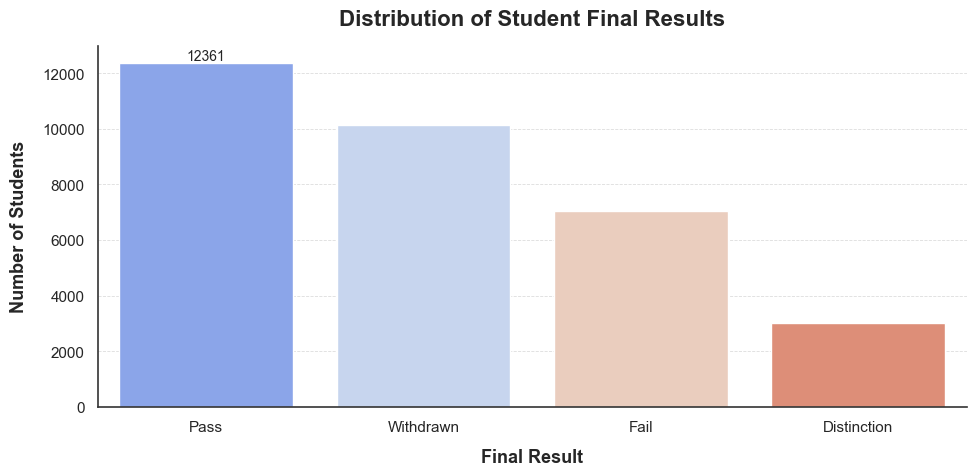

In [ ]:



sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams.update({
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 13,
    "axes.labelweight": "bold",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.figsize": (10, 5),
    "figure.facecolor": "white",
    "axes.edgecolor": "#333333",
    "axes.linewidth": 1.2,
    "grid.color": "#DDDDDD",
    "grid.linestyle": "--",
    "grid.linewidth": 0.6
})


studentRegistration["date_unregistration"] = studentRegistration["date_unregistration"].fillna(-1)
merged_vle = None 


plt.figure()
ax = sns.countplot(
    data=studentInfo,
    x="final_result",
    order=studentInfo["final_result"].value_counts().index,
    palette="coolwarm"
)
ax.set_title("Distribution of Student Final Results", pad=15)
ax.set_xlabel("Final Result", labelpad=10)
ax.set_ylabel("Number of Students", labelpad=10)
ax.bar_label(ax.containers[0], fmt='%d', label_type='edge', fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

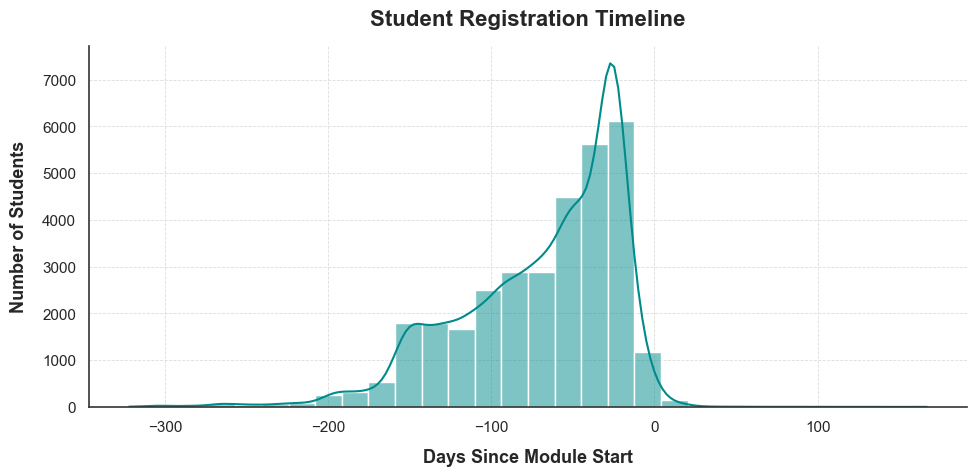

In [ ]:

plt.figure()
sns.histplot(studentRegistration["date_registration"], bins=30, kde=True, color="#008B8B")
plt.title("Student Registration Timeline", pad=15, weight="bold")
plt.xlabel("Days Since Module Start", labelpad=10, weight="bold")
plt.ylabel("Number of Students", labelpad=10, weight="bold")
sns.despine()
plt.tight_layout()
plt.show()

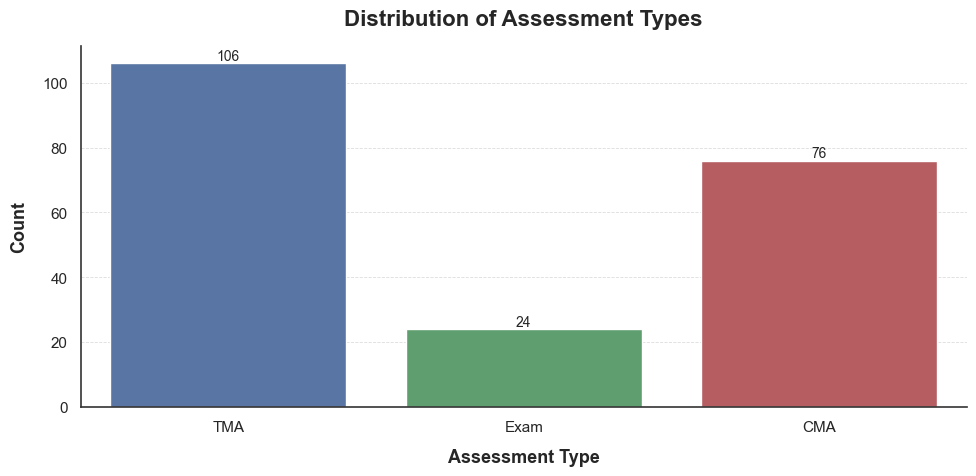

In [ ]:

plt.figure()
ax = sns.countplot(
    data=assessments,
    x="assessment_type",
    palette=["#4C72B0", "#55A868", "#C44E52"]
)
ax.set_title("Distribution of Assessment Types", pad=15, weight="bold")
ax.set_xlabel("Assessment Type", labelpad=10, weight="bold")
ax.set_ylabel("Count", labelpad=10, weight="bold")
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

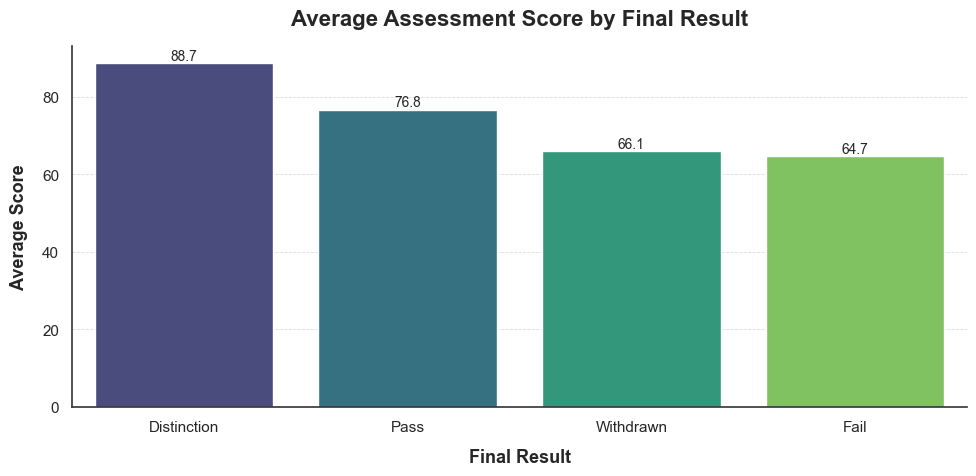

In [ ]:
student_assessment_merged = (
    studentAssessment
    .merge(assessments, on="id_assessment")
    .merge(studentInfo, on=["id_student", "code_module", "code_presentation"])
)

score_summary = (
    student_assessment_merged.groupby("final_result")["score"]
    .mean()
    .reset_index()
    .sort_values("score", ascending=False)
)

plt.figure()
ax = sns.barplot(
    data=score_summary,
    x="final_result",
    y="score",
    hue="final_result",
    dodge=False,
    palette="viridis",
    legend=False
)
ax.set_title("Average Assessment Score by Final Result", pad=15, weight="bold")
ax.set_xlabel("Final Result", labelpad=10, weight="bold")
ax.set_ylabel("Average Score", labelpad=10, weight="bold")
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

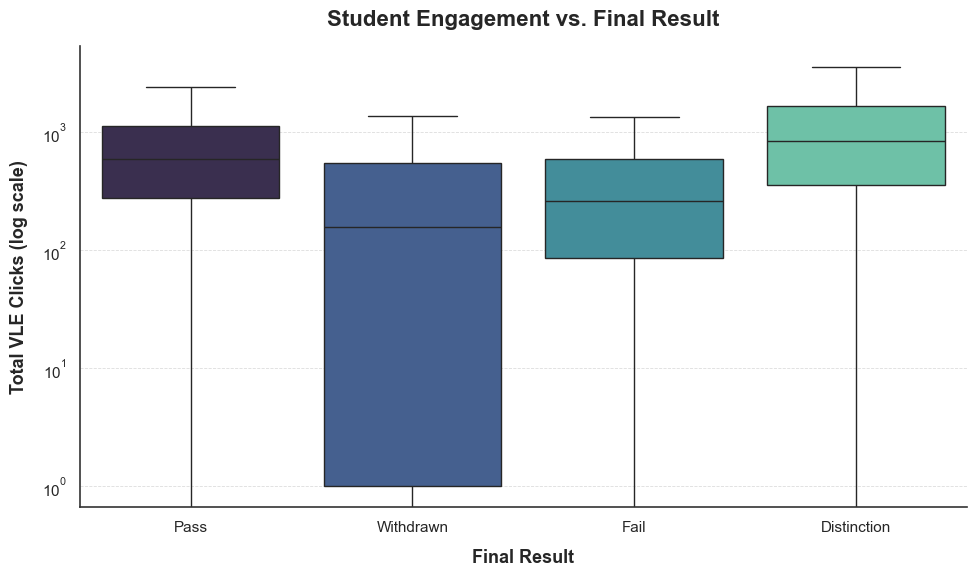

In [ ]:

CUTOFF_DAY = 70 
vle_filtered = studentVle[studentVle['date'] <= CUTOFF_DAY]

vle_activity = vle_filtered.merge(vle, on=["id_site", "code_module", "code_presentation"])

vle_activity_summary = (
    vle_activity.groupby("id_student")["sum_click"]
    .sum()
    .reset_index(name="total_clicks")
)

merged_vle = studentInfo.merge(vle_activity_summary, on="id_student", how="left")
merged_vle["total_clicks"] = merged_vle["total_clicks"].fillna(0)

plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=merged_vle,
    x="final_result",
    y="total_clicks",
    palette="mako",
    showfliers=False
)
ax.set_yscale("log")
ax.set_title("Student Engagement vs. Final Result", pad=15, weight="bold")
ax.set_xlabel("Final Result", labelpad=10, weight="bold")
ax.set_ylabel("Total VLE Clicks (log scale)", labelpad=10, weight="bold")
sns.despine()
plt.tight_layout()
plt.show()

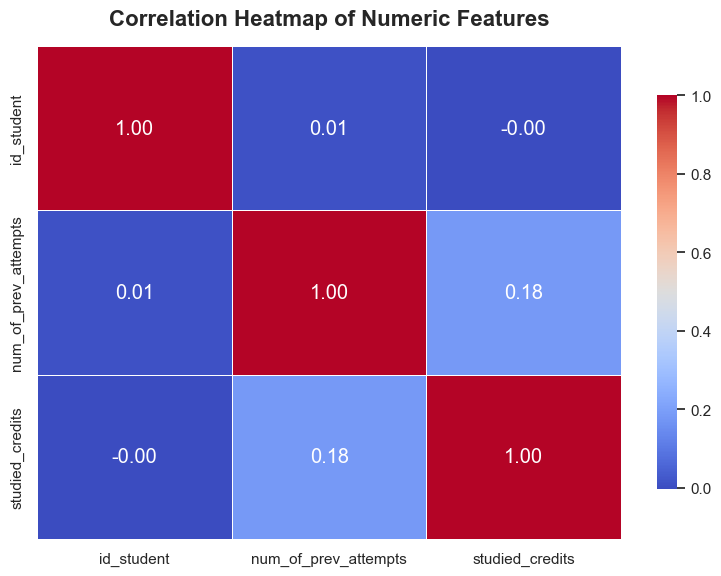

In [ ]:

num_features = studentInfo.select_dtypes(include=[np.number])

plt.figure(figsize=(8, 6))
ax = sns.heatmap(
    num_features.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.6,
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Correlation Heatmap of Numeric Features", pad=15, weight="bold")
plt.tight_layout()
plt.show()

In [ ]:

data_path = 'C:\\Users\\acer\\Desktop\\PhD materials\\Manuscripts\\DataSets\\anonymisedData\\'


files = [f for f in os.listdir(data_path) if f.endswith(".csv")]

for file in files:
    df = pd.read_csv(os.path.join(data_path, file))
    print(f"\n {file}")
    print("-" * (len(file) + 3))
    print(df.columns.tolist())
    print(f"Total columns: {len(df.columns)} | Total rows: {len(df)}")


 assessments.csv
------------------
['code_module', 'code_presentation', 'id_assessment', 'assessment_type', 'date', 'weight']
Total columns: 6 | Total rows: 206

 courses.csv
--------------
['code_module', 'code_presentation', 'module_presentation_length']
Total columns: 3 | Total rows: 22

 oulad_preprocessed_noleak.csv
--------------------------------
['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'avg_score', 'num_assessments', 'first_submission', 'last_submission', 'weighted_score', 'performance_trend', 'total_clicks', 'avg_clicks_per_visit', 'max_clicks_per_visit', 'std_clicks', 'active_days', 'last_activity_day', 'unique_vle_sites', 'clicks_per_active_day', 'revisit_ratio', 'study_duration', 'first_registration', 'activity_entropy', 'avg_gap_between_logins', 'burstiness_index', 'engagement_efficiency', 'cbii', 'tpi', 'dropout_risk_proxy',

In [ ]:
CUTOFF_DAY = 30  

DATA_PATH = 'C:\\Users\\acer\\Desktop\\PhD materials\\Manuscripts\\DataSets\\anonymisedData\\'

assessments         = pd.read_csv(f"{DATA_PATH}/assessments.csv")
courses             = pd.read_csv(f"{DATA_PATH}/courses.csv")
studentAssessment   = pd.read_csv(f"{DATA_PATH}/studentAssessment.csv")
studentInfo         = pd.read_csv(f"{DATA_PATH}/studentInfo.csv")
studentRegistration = pd.read_csv(f"{DATA_PATH}/studentRegistration.csv")
studentVle          = pd.read_csv(f"{DATA_PATH}/studentVle.csv")
vle                 = pd.read_csv(f"{DATA_PATH}/vle.csv")

print("Files loaded. Shapes:")
for name, d in [("assessments",assessments),("studentAssessment",studentAssessment),
                ("studentInfo",studentInfo),("studentRegistration",studentRegistration),
                ("studentVle",studentVle),("vle",vle),("courses",courses)]:
    print(f"  {name}: {d.shape}")


for df in [assessments, studentAssessment, studentInfo, studentRegistration, studentVle, vle, courses]:
    df.replace("?", np.nan, inplace=True)

studentVle = studentVle.assign(
    date=pd.to_numeric(studentVle["date"], errors="coerce").fillna(0).astype(int))
studentAssessment = studentAssessment.assign(
    date_submitted=pd.to_numeric(studentAssessment["date_submitted"], errors="coerce").fillna(0).astype(int))
assessments = assessments.assign(
    date=pd.to_numeric(assessments["date"], errors="coerce").fillna(0).astype(int))
studentRegistration = studentRegistration.assign(
    date_registration=pd.to_numeric(studentRegistration["date_registration"], errors="coerce").fillna(0).astype(int),
    date_unregistration=pd.to_numeric(studentRegistration["date_unregistration"], errors="coerce").fillna(-1).astype(int)
)
studentInfo = studentInfo.copy()
studentInfo["imd_band"] = studentInfo["imd_band"].fillna("Unknown")

studentVle_cut = studentVle[studentVle["date"] <= CUTOFF_DAY].copy()
print(f"\n[CUTOFF={CUTOFF_DAY}] VLE rows used: {len(studentVle_cut):,} / {len(studentVle):,}")

vle_activity = pd.merge(
    studentVle_cut,
    vle,
    on=["id_site", "code_module", "code_presentation"],
    how="left",
    validate="m:1"
)

behav_agg = (
    vle_activity
    .groupby(["id_student", "code_module", "code_presentation"], as_index=False)
    .agg(
        total_clicks         = ("sum_click", "sum"),
        avg_clicks_per_visit = ("sum_click", "mean"),
        max_clicks_per_visit = ("sum_click", "max"),
        std_clicks           = ("sum_click", "std"),
        active_days          = ("date", pd.Series.nunique),
        last_activity_day    = ("date", "max"),
        unique_vle_sites     = ("id_site", pd.Series.nunique)
    )
)
behav_agg["std_clicks"] = behav_agg["std_clicks"].fillna(0)
behav_agg["clicks_per_active_day"] = behav_agg["total_clicks"] / (behav_agg["active_days"] + 1)
behav_agg["revisit_ratio"] = behav_agg["total_clicks"] / (behav_agg["unique_vle_sites"] + 1)

courses_small = courses.copy()
reg = pd.merge(studentRegistration, courses_small, on=["code_module","code_presentation"], how="left")


reg["module_presentation_length"] = pd.to_numeric(
    reg["module_presentation_length"], errors="coerce")
reg["study_duration"] = (
    reg["module_presentation_length"] - reg["date_registration"]
).clip(0).fillna(0)

reg_agg = reg.groupby(["id_student","code_module","code_presentation"], as_index=False).agg(
    study_duration   = ("study_duration", "mean"),
    first_registration = ("date_registration", "min")
)


studentAssessment_cut = studentAssessment[studentAssessment["date_submitted"] <= CUTOFF_DAY].copy()
print(f"[CUTOFF={CUTOFF_DAY}] Assessment rows used: {len(studentAssessment_cut):,} / {len(studentAssessment):,}")

assess_merged = pd.merge(studentAssessment_cut, assessments, on="id_assessment", how="left", validate="m:1")

def safe_weighted_avg(scores, weights):
    wsum = np.nansum(weights)
    if wsum == 0:
        return np.nanmean(scores) if len(scores) > 0 else 0.0
    return np.nansum(scores * weights) / wsum

perf_groups = assess_merged.groupby(["id_student","code_module","code_presentation"], as_index=False)
perf_agg = perf_groups.agg(
    avg_score        = ("score", "mean"),
    num_assessments  = ("id_assessment", "nunique"),
    first_submission = ("date_submitted", "min"),
    last_submission  = ("date_submitted", "max")
)

weighted_list = []
for (student, module, pres), group in perf_groups:
    scores  = group["score"].to_numpy(dtype=float)
    weights = group["weight"].to_numpy(dtype=float) if "weight" in group.columns else np.ones(len(group))
    wavg    = safe_weighted_avg(scores, weights)
    weighted_list.append((student, module, pres, 0.0 if np.isnan(wavg) else wavg))
weighted_df = pd.DataFrame(weighted_list, columns=["id_student","code_module","code_presentation","weighted_score"])
perf_agg = pd.merge(perf_agg, weighted_df, on=["id_student","code_module","code_presentation"], how="left")
perf_agg["avg_score"]      = perf_agg["avg_score"].fillna(0)
perf_agg["weighted_score"] = perf_agg["weighted_score"].fillna(perf_agg["avg_score"])

from sklearn.linear_model import LinearRegression as _LR
def compute_performance_trend(subdf):
    subdf = subdf.dropna(subset=["score","date"]).sort_values("date")
    if len(subdf) < 2:
        return 0.0
    try:
        X_ = np.arange(len(subdf)).reshape(-1,1)
        y_ = subdf["score"].to_numpy(dtype=float)
        y_ = np.nan_to_num(y_, nan=np.nanmean(y_))
        return float(_LR().fit(X_, y_).coef_[0])
    except:
        return 0.0

trend_list = [
    (s, m, p, compute_performance_trend(g))
    for (s, m, p), g in assess_merged.groupby(["id_student","code_module","code_presentation"])
]
trend_df = pd.DataFrame(trend_list, columns=["id_student","code_module","code_presentation","performance_trend"])
perf_agg = pd.merge(perf_agg, trend_df, on=["id_student","code_module","code_presentation"], how="left")
perf_agg["performance_trend"] = perf_agg["performance_trend"].fillna(0)

vle_daily = studentVle_cut.groupby(
    ["id_student","code_module","code_presentation","date"], as_index=False)["sum_click"].sum()

ent_list, gap_list, burst_list = [], [], []
for (student, module, pres), grp in vle_daily.groupby(["id_student","code_module","code_presentation"]):
    clicks = grp["sum_click"].to_numpy(dtype=float)
    p   = clicks / (clicks.sum() + 1e-9)
    ent = entropy(p + 1e-12) if len(p) > 0 else 0.0
    days = np.sort(grp["date"].to_numpy(dtype=int))
    if len(days) < 2:
        avg_gap = burst = 0.0
    else:
        diffs   = np.diff(days)
        avg_gap = float(np.mean(diffs))
        burst   = float(np.std(diffs) / (np.mean(diffs) + 1e-9))
    ent_list.append((student, module, pres, ent))
    gap_list.append((student, module, pres, avg_gap))
    burst_list.append((student, module, pres, burst))

ent_df   = pd.DataFrame(ent_list,   columns=["id_student","code_module","code_presentation","activity_entropy"])
gap_df   = pd.DataFrame(gap_list,   columns=["id_student","code_module","code_presentation","avg_gap_between_logins"])
burst_df = pd.DataFrame(burst_list, columns=["id_student","code_module","code_presentation","burstiness_index"])


master = studentInfo.copy()
master = pd.merge(master, perf_agg,  on=["id_student","code_module","code_presentation"], how="left")
master = pd.merge(master, behav_agg, on=["id_student","code_module","code_presentation"], how="left")
master = pd.merge(master, reg_agg,   on=["id_student","code_module","code_presentation"], how="left")
master = pd.merge(master, ent_df,    on=["id_student","code_module","code_presentation"], how="left")
master = pd.merge(master, gap_df,    on=["id_student","code_module","code_presentation"], how="left")
master = pd.merge(master, burst_df,  on=["id_student","code_module","code_presentation"], how="left")

num_cols = master.select_dtypes(include=[np.number]).columns.tolist()
master[num_cols] = master[num_cols].fillna(0)


master["engagement_efficiency"] = (master["avg_score"] + 1) / (master["total_clicks"] + 1)
master["cbii"] = (
    0.55 * (master["weighted_score"] / (master["weighted_score"].max() + 1e-9)) +
    0.30 * (1 / (1 + master["activity_entropy"])) +
    0.15 * (master["performance_trend"] / (abs(master["performance_trend"]).max() + 1e-9))
)
master["tpi"]               = master["study_duration"] / (master["num_assessments"] + 1)
master["dropout_risk_proxy"] = (
    0.4 * (1 / (1 + master["study_duration"])) +
    0.3 * (1 / (1 + master["clicks_per_active_day"])) +
    0.3 * (1 / (1 + master["weighted_score"]))
)


if "final_result" in master.columns:
    master["final_result"] = master["final_result"].astype(str).fillna("Unknown")
    target_le = LabelEncoder()
    master["target_result"] = target_le.fit_transform(master["final_result"])
    print("Target classes:", list(target_le.classes_))
else:
    master["target_result"] = 0


master = master.replace([np.inf, -np.inf], 0).fillna(0)

OUT_PATH_PREP = "C:/Users/acer/Desktop/PhD materials/Manuscripts/Helping Docs/oulad_preprocessed_noleak.csv"
master.to_csv(OUT_PATH_PREP, index=False)

print(f"\nPreprocessing complete (No Leakage). Shape: {master.shape}")
print(f"Saved to: {OUT_PATH_PREP}")
print("\nSample columns:")
print(master[["id_student","avg_score","weighted_score","total_clicks",
              "activity_entropy","burstiness_index","cbii","tpi","target_result"]].head(4))


Files loaded. Shapes:
  assessments: (206, 6)
  studentAssessment: (173912, 5)
  studentInfo: (32593, 12)
  studentRegistration: (32593, 5)
  studentVle: (10655280, 6)
  vle: (6364, 6)
  courses: (22, 3)

[CUTOFF=30] VLE rows used: 2,980,575 / 10,655,280
[CUTOFF=30] Assessment rows used: 26,522 / 173,912
Target classes: ['Distinction', 'Fail', 'Pass', 'Withdrawn']

Preprocessing complete (No Leakage). Shape: (32593, 37)
Saved to: C:/Users/acer/Desktop/PhD materials/Manuscripts/Helping Docs/oulad_preprocessed_noleak.csv

Sample columns:
   id_student  avg_score  weighted_score  total_clicks  activity_entropy  \
0       11391       78.0            78.0         424.0          1.862730   
1       28400       70.0            70.0         618.0          2.640609   
2       30268        0.0             0.0         281.0          2.211387   
3       31604       72.0            72.0         540.0          2.799516   

   burstiness_index      cbii    tpi  target_result  
0          0.869436  0.

In [ ]:
try:
    import xgboost as xgb
except ImportError:
    import subprocess, sys

    subprocess.run([sys.executable, "-m", "pip", "install", "xgboost"])
    import xgboost as xgb

print("XGBoost is ready!")

XGBoost is ready!


In [ ]:
PREP_PATH = r"C:/Users/acer/Desktop/PhD materials/Manuscripts/Helping Docs/oulad_preprocessed_noleak.csv"
assert os.path.exists(PREP_PATH), f"File not found: {PREP_PATH}"

df = pd.read_csv(PREP_PATH)
print("Loaded preprocessed data:", df.shape)


if "target_result" in df.columns:
    target_col = "target_result"
elif "final_result" in df.columns:
    df["target_result"] = pd.factorize(df["final_result"].astype(str))[0]
    target_col = "target_result"
else:
    raise ValueError("No target column found.")

CAT_COLS = ["gender","region","highest_education","imd_band","age_band","disability",
            "code_module","code_presentation"]

exclude = {"id_student","final_result", target_col}
feature_cols = [c for c in df.columns if c not in exclude]

X_raw = df[feature_cols].copy()
y     = df[target_col].copy().astype(int)

print(f"Feature matrix (raw, unscaled): {X_raw.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True).round(3)}")


Loaded preprocessed data: (32593, 37)
Feature matrix (raw, unscaled): (32593, 34)
Target distribution:
target_result
2    0.379
3    0.312
1    0.216
0    0.093
Name: proportion, dtype: float64


In [ ]:
RANDOM_STATE = 42

X_temp_raw, X_test_raw, y_temp, y_test = train_test_split(
    X_raw, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp_raw, y_temp, test_size=0.20, stratify=y_temp, random_state=RANDOM_STATE)

print(f"Sizes -> Train: {X_train_raw.shape}, Val: {X_val_raw.shape}, Test: {X_test_raw.shape}")

cat_encoders = {}
X_train_enc = X_train_raw.copy()
X_val_enc   = X_val_raw.copy()
X_test_enc  = X_test_raw.copy()

for col in CAT_COLS:
    if col not in X_train_enc.columns:
        continue
    le = LabelEncoder()
    le.fit(X_train_enc[col].astype(str))
    cat_encoders[col] = le
    seen = set(le.classes_)
    for split_df in [X_train_enc, X_val_enc, X_test_enc]:
        split_df[col] = split_df[col].astype(str).apply(
            lambda v: v if v in seen else le.classes_[0])
        split_df[col] = le.transform(split_df[col])

print(f"Categorical columns encoded: {list(cat_encoders.keys())}")


X_train_enc = X_train_enc.fillna(0).astype(float)
X_val_enc   = X_val_enc.fillna(0).astype(float)
X_test_enc  = X_test_enc.fillna(0).astype(float)

scaler_main = StandardScaler()
X_train = pd.DataFrame(scaler_main.fit_transform(X_train_enc),
                        columns=feature_cols, index=X_train_enc.index)
X_val   = pd.DataFrame(scaler_main.transform(X_val_enc),
                        columns=feature_cols, index=X_val_enc.index)
X_test  = pd.DataFrame(scaler_main.transform(X_test_enc),
                        columns=feature_cols, index=X_test_enc.index)

print(f"Train scaled: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print("No data leakage: scaler fitted on training set only.")


Sizes -> Train: (20859, 34), Val: (5215, 34), Test: (6519, 34)
Categorical columns encoded: ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability', 'code_module', 'code_presentation']
Train scaled: (20859, 34), Val: (5215, 34), Test: (6519, 34)
No data leakage: scaler fitted on training set only.


In [ ]:
def compute_metrics(y_true, y_pred, y_prob=None, average="macro"):
    metrics = {}
    metrics["accuracy"]  = accuracy_score(y_true, y_pred)
    metrics["precision"] = precision_score(y_true, y_pred, average=average, zero_division=0)
    metrics["recall"]    = recall_score(y_true, y_pred, average=average, zero_division=0)
    metrics["f1"]        = f1_score(y_true, y_pred, average=average, zero_division=0)
    if y_prob is not None and len(np.unique(y_true)) > 2:
        try:
            metrics["roc_auc_ovr"] = roc_auc_score(
                pd.get_dummies(y_true), y_prob, average="macro", multi_class="ovr")
        except Exception:
            metrics["roc_auc_ovr"] = np.nan
    else:
        metrics["roc_auc_ovr"] = np.nan
    return metrics


SKF = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

def cross_validate_model(clf_factory, X_raw_df, y_series, skf=SKF):
    """
    Performs stratified K-fold cross-validation on the given raw feature DataFrame and target Series.
    For each fold, it scales the features, trains the classifier, and computes performance metrics.
    Returns the average metrics across folds and a DataFrame of fold-wise metrics.
     --- IGNORE ---
     Parameters:
     - clf_factory: A function that returns a new instance of the classifier to be evaluated.
     - X_raw_df: A pandas DataFrame containing the raw (unscaled) features.
     - y_series: A pandas Series containing the target labels.
     - skf: An instance of StratifiedKFold for splitting the data (default is 10 folds with shuffling).
     Returns:
     - A dictionary of average metrics across all folds.
     - A DataFrame containing the metrics for each fold.
     Note: The function ensures that the scaling is done within each fold to prevent data leakage.
     The metrics computed include accuracy, precision, recall, F1-score, and ROC AUC (if applicable).
    """
    fold_metrics = []
    for fold, (tr_idx, va_idx) in enumerate(skf.split(X_raw_df, y_series), 1):
        X_tr_raw = X_raw_df.iloc[tr_idx]
        X_va_raw = X_raw_df.iloc[va_idx]
        y_tr = y_series.iloc[tr_idx]
        y_va = y_series.iloc[va_idx]

        sc_fold = StandardScaler()
        X_tr_s = sc_fold.fit_transform(X_tr_raw)
        X_va_s = sc_fold.transform(X_va_raw)

        clf = clf_factory()
        clf.fit(X_tr_s, y_tr)
        y_pred = clf.predict(X_va_s)
        y_prob = clf.predict_proba(X_va_s) if hasattr(clf, "predict_proba") else None
        m = compute_metrics(y_va, y_pred, y_prob)
        fold_metrics.append(m)
        print(f"  Fold {fold:2d} -> acc: {m['accuracy']:.4f}, f1: {m['f1']:.4f}")

    dfm = pd.DataFrame(fold_metrics)
    return dfm.mean().to_dict(), dfm


In [ ]:

def xgb_factory():
    return xgb.XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        use_label_encoder=False,
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    )

def rf_factory():
    return RandomForestClassifier(
        n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)


def lr_factory():
    return LogisticRegression(
        max_iter=2000, random_state=RANDOM_STATE, solver="saga")


In [ ]:

print("\n=== 10-fold CV: XGBoost ===")
xgb_cv_mean, xgb_cv_folds = cross_validate_model(xgb_factory, X_train_enc, y_train)

print("\n=== 10-fold CV: RandomForest ===")
rf_cv_mean, rf_cv_folds = cross_validate_model(rf_factory, X_train_enc, y_train)

print("\n=== 10-fold CV: LogisticRegression ===")
lr_cv_mean, lr_cv_folds = cross_validate_model(lr_factory, X_train_enc, y_train)

cv_summary = pd.DataFrame({
    "XGBoost":            xgb_cv_mean,
    "RandomForest":       rf_cv_mean,
    "LogisticRegression": lr_cv_mean
}).T
print("\nCross-validation summary (mean across folds):")
print(cv_summary[["accuracy","precision","recall","f1","roc_auc_ovr"]])



=== 10-fold CV: XGBoost ===
  Fold  1 -> acc: 0.5834, f1: 0.4930
  Fold  2 -> acc: 0.5652, f1: 0.4707
  Fold  3 -> acc: 0.5925, f1: 0.4896
  Fold  4 -> acc: 0.5594, f1: 0.4601
  Fold  5 -> acc: 0.5657, f1: 0.4637
  Fold  6 -> acc: 0.5748, f1: 0.4775
  Fold  7 -> acc: 0.5887, f1: 0.4908
  Fold  8 -> acc: 0.5791, f1: 0.4849
  Fold  9 -> acc: 0.5887, f1: 0.4974
  Fold 10 -> acc: 0.5616, f1: 0.4619

=== 10-fold CV: RandomForest ===
  Fold  1 -> acc: 0.5781, f1: 0.4594
  Fold  2 -> acc: 0.5666, f1: 0.4537
  Fold  3 -> acc: 0.5820, f1: 0.4747
  Fold  4 -> acc: 0.5609, f1: 0.4483
  Fold  5 -> acc: 0.5801, f1: 0.4631
  Fold  6 -> acc: 0.5705, f1: 0.4589
  Fold  7 -> acc: 0.5690, f1: 0.4461
  Fold  8 -> acc: 0.5810, f1: 0.4704
  Fold  9 -> acc: 0.5872, f1: 0.4657
  Fold 10 -> acc: 0.5635, f1: 0.4479

=== 10-fold CV: LogisticRegression ===
  Fold  1 -> acc: 0.5518, f1: 0.4029
  Fold  2 -> acc: 0.5479, f1: 0.4018
  Fold  3 -> acc: 0.5671, f1: 0.4111
  Fold  4 -> acc: 0.5508, f1: 0.4010
  Fold  5

In [ ]:
print("\nTraining final XGBoost with early stopping on validation set...")
model_xgb = xgb_factory()

model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=10
)
os.makedirs(os.path.join(DATA_PATH, "models"), exist_ok=True)
joblib.dump(model_xgb, os.path.join(DATA_PATH, "models", "xgb_final.joblib"))


Training final XGBoost with early stopping on validation set...
[0]	validation_0-mlogloss:1.24786
[10]	validation_0-mlogloss:1.07673
[20]	validation_0-mlogloss:1.02396
[30]	validation_0-mlogloss:1.00278
[40]	validation_0-mlogloss:0.99237
[50]	validation_0-mlogloss:0.98789
[60]	validation_0-mlogloss:0.98556
[70]	validation_0-mlogloss:0.98392
[80]	validation_0-mlogloss:0.98319
[90]	validation_0-mlogloss:0.98332
[100]	validation_0-mlogloss:0.98354
[110]	validation_0-mlogloss:0.98416
[120]	validation_0-mlogloss:0.98530
[130]	validation_0-mlogloss:0.98715
[140]	validation_0-mlogloss:0.98842
[150]	validation_0-mlogloss:0.98949
[160]	validation_0-mlogloss:0.99102
[170]	validation_0-mlogloss:0.99220
[180]	validation_0-mlogloss:0.99358
[190]	validation_0-mlogloss:0.99515
[199]	validation_0-mlogloss:0.99666


['C:\\Users\\acer\\Desktop\\PhD materials\\Manuscripts\\DataSets\\anonymisedData\\models\\xgb_final.joblib']


=== Test set evaluation (XGBoost) ===
accuracy       0.576162
precision      0.540472
recall         0.472914
f1             0.480863
roc_auc_ovr    0.794975
dtype: float64

Classification report:
              precision    recall  f1-score   support

           0       0.46      0.19      0.27       605
           1       0.45      0.27      0.34      1411
           2       0.55      0.80      0.65      2472
           3       0.70      0.63      0.67      2031

    accuracy                           0.58      6519
   macro avg       0.54      0.47      0.48      6519
weighted avg       0.57      0.58      0.55      6519



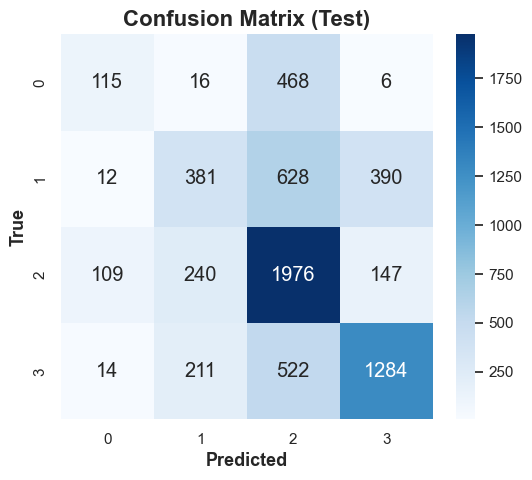

In [ ]:
y_test_pred = model_xgb.predict(X_test)
y_test_prob = model_xgb.predict_proba(X_test) if hasattr(model_xgb, "predict_proba") else None
test_metrics = compute_metrics(y_test, y_test_pred, y_test_prob)
print("\n=== Test set evaluation (XGBoost) ===")
print(pd.Series(test_metrics))

print("\nClassification report:")
print(classification_report(y_test, y_test_pred, zero_division=0))


plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
print("=== RandomForest: Final Training & Test Evaluation ===")
model_rf = rf_factory()
model_rf.fit(X_train, y_train)

y_rf_pred = model_rf.predict(X_test)
y_rf_prob = model_rf.predict_proba(X_test)
rf_test   = compute_metrics(y_test, y_rf_pred, y_rf_prob)

print(pd.Series(rf_test))
print("\nClassification Report (RF):")
print(classification_report(y_test, y_rf_pred, target_names=['Distinction', 'Fail', 'Pass', 'Withdrawn']))

print("=== LogisticRegression: Final Training & Test Evaluation ===")
model_lr = lr_factory()
model_lr.fit(X_train, y_train)

y_lr_pred = model_lr.predict(X_test)
y_lr_prob = model_lr.predict_proba(X_test)
lr_test   = compute_metrics(y_test, y_lr_pred, y_lr_prob)

print(pd.Series(lr_test))
print("Classification Report (LR):")
print(classification_report(y_test, y_lr_pred,
      target_names=["Distinction","Fail","Pass","Withdrawn"]))

print("\n" + "="*65)
print("CLEAN RESULTS SUMMARY (Test Set) — No Data Leakage")
print("="*65)

summary_df = pd.DataFrame({
    "XGBoost":            test_metrics,
    "RandomForest":       rf_test,
    "LogisticRegression": lr_test,
}).T[["accuracy","precision","recall","f1","roc_auc_ovr"]]

summary_df.columns = ["Accuracy","Precision","Recall","F1","AUC"]
summary_df = summary_df.round(4)
print(summary_df.to_string())

summary_df.to_csv(os.path.join(DATA_PATH, "models", "test_results_all_models.csv"))
print("Saved: test_results_all_models.csv")


=== RandomForest: Final Training & Test Evaluation ===
accuracy       0.571100
precision      0.542761
recall         0.452743
f1             0.453468
roc_auc_ovr    0.784555
dtype: float64

Classification Report (RF):
              precision    recall  f1-score   support

 Distinction       0.51      0.14      0.22       605
        Fail       0.42      0.21      0.28      1411
        Pass       0.54      0.85      0.66      2472
   Withdrawn       0.70      0.62      0.66      2031

    accuracy                           0.57      6519
   macro avg       0.54      0.45      0.45      6519
weighted avg       0.56      0.57      0.54      6519

=== LogisticRegression: Final Training & Test Evaluation ===
accuracy       0.557294
precision      0.550966
recall         0.423953
f1             0.407770
roc_auc_ovr    0.767119
dtype: float64
Classification Report (LR):
              precision    recall  f1-score   support

 Distinction       0.58      0.02      0.05       605
        Fail 


Computing permutation importance on validation set...


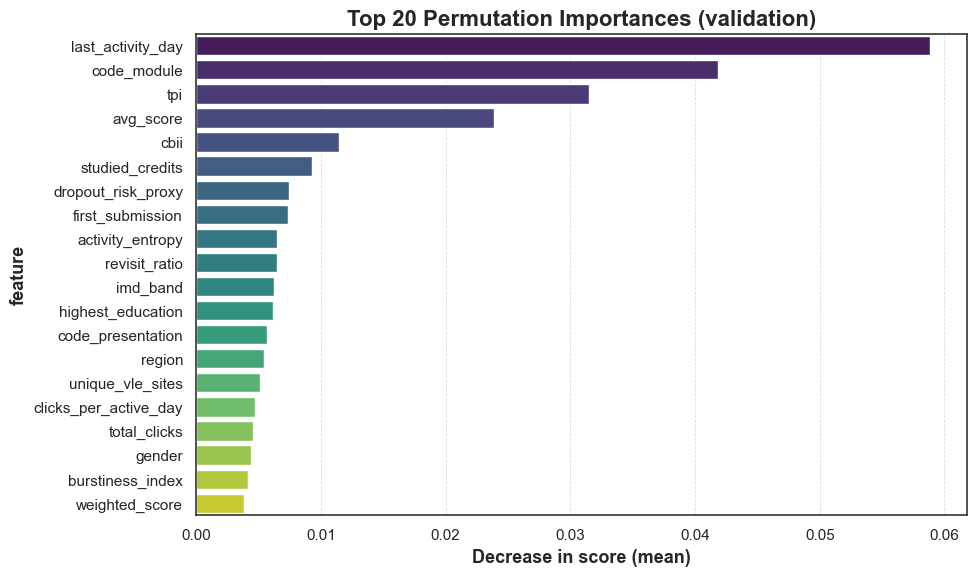

In [ ]:
print("\nComputing permutation importance on validation set...")
perm_res = permutation_importance(model_xgb, X_val, y_val, n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
perm_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": perm_res.importances_mean,
    "importance_std": perm_res.importances_std
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10,6))
sns.barplot(data=perm_df.head(20), x="importance_mean", y="feature", palette="viridis")
plt.title("Top 20 Permutation Importances (validation)")
plt.xlabel("Decrease in score (mean)")
plt.tight_layout()
plt.show()

Using existing trained XGBoost model.
SHAP input: full=(6519, 34), using sample=(2000, 34)
Trying TreeExplainer (model_output=raw)...
TreeExplainer succeeded. Shape: (2000, 34, 4)
SHAP values ready using TreeExplainer (model_output=raw). Shape: (2000, 34, 4)
Top 10 SHAP features:
           feature  shap_mean_abs
 last_activity_day       0.271129
         avg_score       0.234733
       code_module       0.226711
 highest_education       0.137773
    weighted_score       0.116941
              cbii       0.096840
dropout_risk_proxy       0.093348
               tpi       0.087457
          imd_band       0.086335
  activity_entropy       0.082689


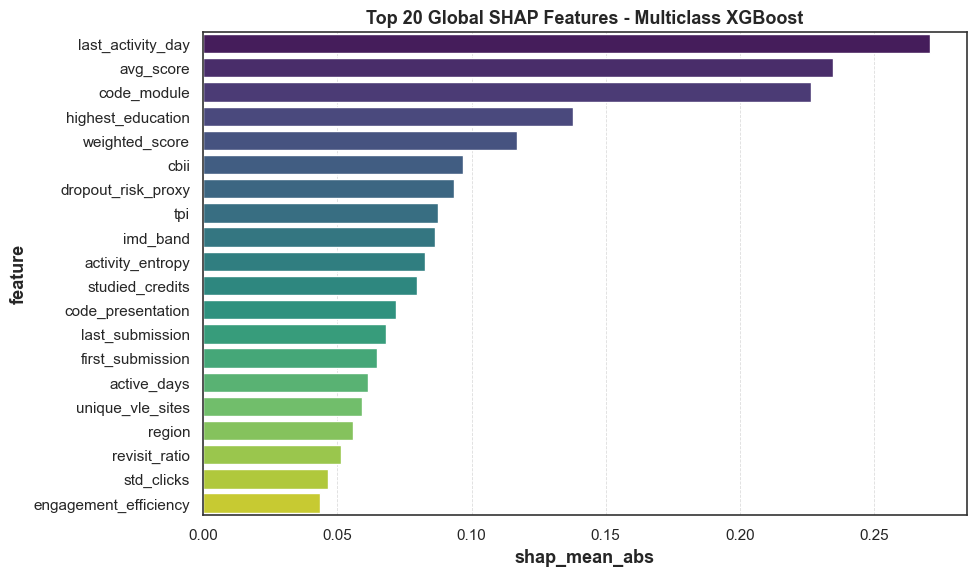

Top 5 features for class 0:
          feature  mean_abs_shap
        avg_score       0.462546
      code_module       0.336168
   weighted_score       0.283171
highest_education       0.259772
last_activity_day       0.175224
Top 5 features for class 1:
          feature  mean_abs_shap
        avg_score       0.229511
highest_education       0.114694
      active_days       0.100225
code_presentation       0.099958
           region       0.088312
Top 5 features for class 2:
           feature  mean_abs_shap
 last_activity_day       0.392225
       code_module       0.207402
dropout_risk_proxy       0.155272
    weighted_score       0.128599
         avg_score       0.126787
Top 5 features for class 3:
          feature  mean_abs_shap
last_activity_day       0.451829
      code_module       0.287988
  studied_credits       0.170551
              tpi       0.165249
             cbii       0.139508


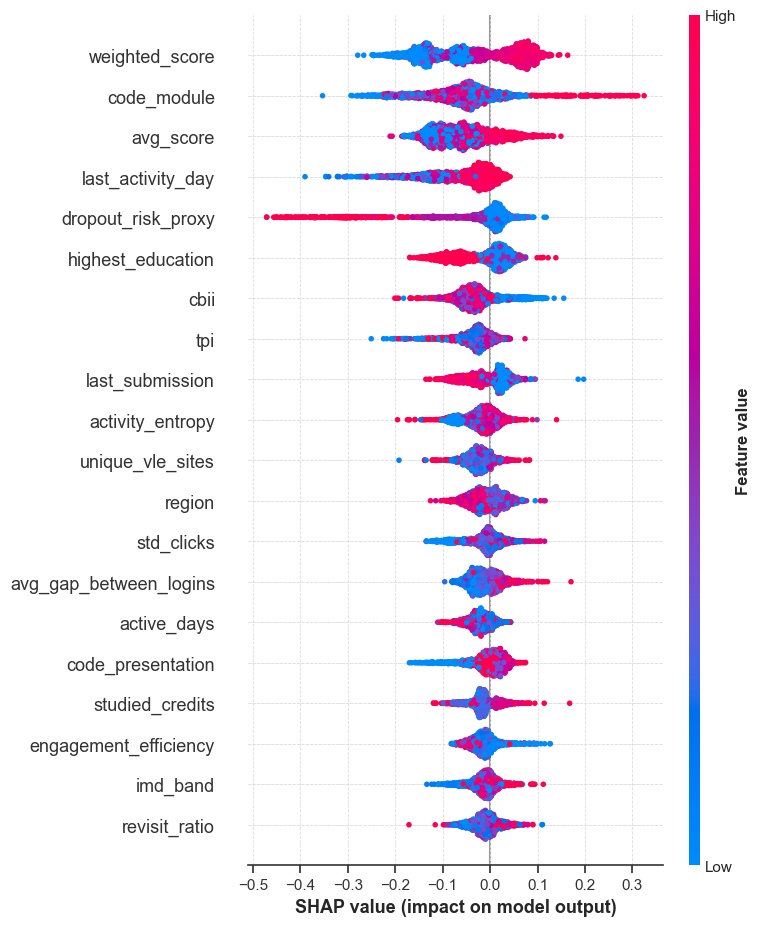

Saved SHAP artifacts to C:\Users\acer\Desktop\PhD materials\Manuscripts\DataSets\anonymisedData\models\shap_artifacts


In [ ]:
MODEL_PATH = os.path.join(DATA_PATH, "models", "xgb_final.joblib")
OUT_DIR    = os.path.join(DATA_PATH, "models", "shap_artifacts")
os.makedirs(OUT_DIR, exist_ok=True)

SAMPLE_FOR_SHAP = min(2000, len(X_test))
RANDOM_STATE    = 42

try:
    model_xgb
    print("Using existing trained XGBoost model.")
except NameError:
    print("Loading saved model from disk...")
    model_xgb = joblib.load(MODEL_PATH)

X_test_full   = X_test.copy().reset_index(drop=True)
X_test_sample = X_test_full.sample(SAMPLE_FOR_SHAP, random_state=RANDOM_STATE)
print(f"SHAP input: full={X_test_full.shape}, using sample={X_test_sample.shape}")

def predict_proba_fn(x):
    if isinstance(x, np.ndarray):
        x = pd.DataFrame(x, columns=X_test_full.columns)
    return model_xgb.predict_proba(x)

shap_vals = None
used_method = None

try:
    print("Trying TreeExplainer (model_output=raw)...")
    explainer_tree = shap.TreeExplainer(model_xgb, model_output="raw")
    shap_vals_raw  = explainer_tree.shap_values(X_test_sample)

    if isinstance(shap_vals_raw, list):
        shap_vals = np.stack(shap_vals_raw, axis=-1) 
    else:
        shap_vals = shap_vals_raw

    used_method = "TreeExplainer (model_output=raw)"
    print(f"TreeExplainer succeeded. Shape: {shap_vals.shape}")

except Exception as e:
    print(f"TreeExplainer failed: {e}")
    print("Fallback: KernelExplainer on small sample...")

    background = shap.sample(X_test_sample, 100, random_state=RANDOM_STATE)
    explainer_kernel = shap.KernelExplainer(predict_proba_fn, background)
    shap_vals_raw = explainer_kernel.shap_values(
        X_test_sample.iloc[:200], nsamples=100
    )

    if isinstance(shap_vals_raw, list):
        shap_vals = np.stack(shap_vals_raw, axis=-1)
    else:
        shap_vals = shap_vals_raw

    X_test_sample = X_test_sample.iloc[:200].reset_index(drop=True)
    used_method = "KernelExplainer"
    print(f"KernelExplainer done. Shape: {shap_vals.shape}")

if shap_vals.ndim == 2:
    shap_vals = shap_vals[:, :, np.newaxis]

print(f"SHAP values ready using {used_method}. Shape: {shap_vals.shape}")


shap_arr = shap_vals
shap_values_eval = shap_vals


mean_abs_shap = np.abs(shap_vals).mean(axis=(0, 2))
shap_global_df = pd.DataFrame({
    "feature": X_test_sample.columns,
    "shap_mean_abs": mean_abs_shap
}).sort_values("shap_mean_abs", ascending=False)

print("Top 10 SHAP features:")
print(shap_global_df.head(10).to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=shap_global_df.head(20), x="shap_mean_abs", y="feature", palette="viridis")
plt.title("Top 20 Global SHAP Features - Multiclass XGBoost", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()


num_cls = shap_vals.shape[2]
for cls_idx in range(num_cls):
    mean_cls = np.abs(shap_vals[:, :, cls_idx]).mean(axis=0)
    top_cls  = pd.DataFrame({
        "feature": X_test_sample.columns,
        "mean_abs_shap": mean_cls
    }).sort_values("mean_abs_shap", ascending=False)
    print(f"Top 5 features for class {cls_idx}:")
    print(top_cls.head(5).to_string(index=False))


shap_mean_across_classes = shap_vals.mean(axis=2)
shap.summary_plot(shap_mean_across_classes, X_test_sample, show=True)

np.save(os.path.join(OUT_DIR, "shap_values.npy"), shap_vals)
shap_global_df.to_csv(os.path.join(OUT_DIR, "shap_global_importance.csv"), index=False)
print(f"Saved SHAP artifacts to {OUT_DIR}")


In [ ]:
perm_df.to_csv(os.path.join(DATA_PATH, "models", "permutation_importance_val.csv"), index=False)
cv_summary.to_csv(os.path.join(DATA_PATH, "models", "cv_summary.csv"))

In [ ]:
try:
    import lime
    from lime.lime_tabular import LimeTabularExplainer
except Exception:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "lime"])
    from lime.lime_tabular import LimeTabularExplainer

import shap


RANDOM_STATE  = 42
N_SAMPLES     = 50    
TOP_K         = 5    
np.random.seed(RANDOM_STATE)

feature_cols = X_train.columns.tolist()
n_features   = len(feature_cols)
n_classes    = len(np.unique(y_train))
print(f"Explaining model with {n_features} features and {n_classes} classes.")
print(f"Using {N_SAMPLES} instances for local explanations.")

def predict_proba_fn(X_in):
    X_df = pd.DataFrame(X_in, columns=feature_cols)
    return model_xgb.predict_proba(X_df)


X_test_eval = X_test.sample(n=min(N_SAMPLES, len(X_test)), random_state=RANDOM_STATE)
print(f"\n--- SHAP: computing explanations ({len(X_test_eval)} samples) ---")
t0 = time.time()

try:
    explainer_shap = shap.TreeExplainer(model_xgb)
    shap_vals_raw  = explainer_shap.shap_values(X_test_eval)
    shap_arr = np.array(shap_vals_raw)
    if shap_arr.ndim == 3 and shap_arr.shape[2] == n_classes:
        pass  
    elif isinstance(shap_vals_raw, list):
        shap_arr = np.stack(shap_vals_raw, axis=-1)  
    print(f"  TreeExplainer succeeded. Shape: {shap_arr.shape}")
    used_method = "TreeExplainer"
except Exception as e:
    print(f"  TreeExplainer failed ({e}), fallback to KernelSHAP (50 samples)...")
    bg = shap.kmeans(X_train, 20)
    explainer_shap = shap.KernelExplainer(predict_proba_fn, bg)
    shap_vals_raw  = explainer_shap.shap_values(X_test_eval, nsamples=50)
    shap_arr = np.array(shap_vals_raw)
    if shap_arr.ndim == 3:
        shap_arr = np.transpose(shap_arr, (1, 2, 0)) 
    used_method = "KernelSHAP"

t_shap = time.time() - t0
print(f"  SHAP done in {t_shap:.1f}s using {used_method}. Array shape: {shap_arr.shape}")

shap_global_mean_abs = np.abs(shap_arr).mean(axis=(0, 2)) 
shap_global_df = pd.DataFrame({"feature": feature_cols, "shap_mean_abs": shap_global_mean_abs})
shap_global_df = shap_global_df.sort_values("shap_mean_abs", ascending=False).reset_index(drop=True)

probs_eval  = model_xgb.predict_proba(X_test_eval)
pred_classes = probs_eval.argmax(axis=1)
shap_local_records = []
for i, idx in enumerate(X_test_eval.index):
    cls    = pred_classes[i]
    signed = shap_arr[i, :, cls] if shap_arr.ndim == 3 else shap_arr[i]
    rec    = {"index": idx, "pred_class": int(cls)}
    for j, feat in enumerate(feature_cols):
        rec[feat] = signed[j]
    shap_local_records.append(rec)
shap_local_df = pd.DataFrame(shap_local_records).set_index("index")

feature_to_group = {
    "avg_score":"Assessment","weighted_score":"Assessment",
    "performance_trend":"Assessment","num_assessments":"Assessment",
    "total_clicks":"Engagement","avg_clicks_per_visit":"Engagement",
    "max_clicks_per_visit":"Engagement","std_clicks":"Engagement",
    "active_days":"Engagement","unique_vle_sites":"Engagement",
    "clicks_per_active_day":"Engagement","revisit_ratio":"Engagement",
    "activity_entropy":"Temporal","avg_gap_between_logins":"Temporal",
    "burstiness_index":"Temporal","last_activity_day":"Temporal",
    "study_duration":"Temporal","tpi":"Temporal",
    "engagement_efficiency":"Composite","cbii":"Composite",
    "dropout_risk_proxy":"Composite",
    "gender":"Demographic","region":"Demographic","highest_education":"Demographic",
    "imd_band":"Demographic","age_band":"Demographic","disability":"Demographic",
}
group_map = {f: feature_to_group.get(f, "Other") for f in feature_cols}

print("\nTop 10 SHAP features:")
print(shap_global_df.head(10).to_string(index=False))

print(f"\n--- LIME: computing local explanations ({N_SAMPLES} samples) ---")
t0 = time.time()
lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_cols,
    class_names=[str(c) for c in np.unique(y_train)],
    discretize_continuous=True,
    random_state=RANDOM_STATE
)

lime_local_records = []
for i, idx in enumerate(X_test_eval.index):
    exp = lime_explainer.explain_instance(
        X_test.loc[idx].values,
        predict_proba_fn,
        num_features=n_features
    )
    pred_cls = int(predict_proba_fn(X_test.loc[[idx]].values).argmax())
    rec = {"index": idx, "pred_class": pred_cls}
    for feat_idx, weight in exp.as_map()[exp.available_labels()[0]]:
        rec[feature_cols[feat_idx]] = abs(weight)
    lime_local_records.append(rec)

lime_local_df = pd.DataFrame(lime_local_records).set_index("index").fillna(0)
t_lime = time.time() - t0
print(f"  LIME done in {t_lime:.1f}s ({t_lime/N_SAMPLES:.2f}s/sample)")

lime_abs_avg   = np.abs(lime_local_df[feature_cols]).mean(axis=0).values
lime_global_df = pd.DataFrame({"feature": feature_cols, "lime_mean_abs": lime_abs_avg})
lime_global_df = lime_global_df.sort_values("lime_mean_abs", ascending=False).reset_index(drop=True)

print("\nTop 10 LIME features:")
print(lime_global_df.head(10).to_string(index=False))


Explaining model with 34 features and 4 classes.
Using 50 instances for local explanations.

--- SHAP: computing explanations (50 samples) ---
  TreeExplainer succeeded. Shape: (50, 34, 4)
  SHAP done in 0.6s using TreeExplainer. Array shape: (50, 34, 4)

Top 10 SHAP features:
           feature  shap_mean_abs
 last_activity_day       0.274069
       code_module       0.238699
         avg_score       0.231692
 highest_education       0.139656
    weighted_score       0.112605
dropout_risk_proxy       0.110417
          imd_band       0.085190
              cbii       0.083166
   studied_credits       0.080798
  activity_entropy       0.076171

--- LIME: computing local explanations (50 samples) ---
  LIME done in 13.6s (0.27s/sample)

Top 10 LIME features:
             feature  lime_mean_abs
           avg_score       0.072977
   code_presentation       0.053532
   highest_education       0.041471
              gender       0.036768
         code_module       0.036227
        total_cl

In [ ]:
print("\n--- LIME: computing local explanations (sampled instances) ---")
t0 = time.time()

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_cols,
    class_names=[str(c) for c in np.unique(y_train)],
    mode="classification",
    random_state=RANDOM_STATE
)

lime_local_records = []
lime_times = []

for idx in X_test_eval.index:
    x_row = X_test.loc[idx, feature_cols].values
    t1 = time.time()
    exp = lime_explainer.explain_instance(
        x_row, predict_proba_fn, num_features=min(20, n_features)
    )
    t2 = time.time()
    lime_times.append(t2 - t1)

    probs = model_xgb.predict_proba(pd.DataFrame([x_row], columns=feature_cols))[0]
    pred_class = int(np.argmax(probs))

    if pred_class not in exp.local_exp:
        available_classes = list(exp.local_exp.keys())
        pred_class = available_classes[0] 

    local_list = exp.as_list(label=pred_class)
    local_dict = {feat: weight for (feat, weight) in local_list}

    rec = {"index": idx, "pred_class": pred_class}
    for f in feature_cols:
        rec[f] = local_dict.get(f, 0.0)
    lime_local_records.append(rec)

t_lime = time.time() - t0
print(f"LIME computed for {len(lime_local_records)} instances in {t_lime:.1f}s. "
      f"avg per-instance {np.mean(lime_times):.2f}s")

lime_local_df = pd.DataFrame(lime_local_records).set_index("index")



--- LIME: computing local explanations (sampled instances) ---
LIME computed for 50 instances in 12.5s. avg per-instance 0.23s



--- Adaptive Fidelity-Weighted Hybrid SHAP-LIME ---
    (Methodological Contribution: per-instance adaptive weights)

  Mean adaptive SHAP weight: 0.574 (0.5=equal, >0.5=SHAP preferred)
  Instances where SHAP dominates (w>0.6): 22 (44.0%)
  Instances where LIME dominates (w<0.4): 12 (24.0%)


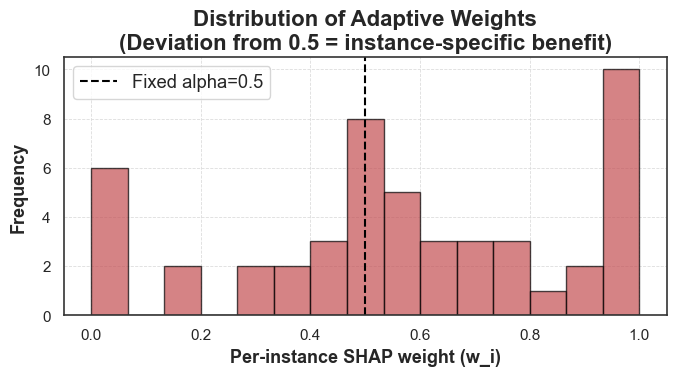

In [ ]:
print("\n--- Adaptive Fidelity-Weighted Hybrid SHAP-LIME ---")
print("    (Methodological Contribution: per-instance adaptive weights)")


baseline_values = X_train.median().values

def normalize_sum(v):
    """To compare min-max normalized SHAP and LIME scores, we can also try sum normalization (L1 norm) which preserves sparsity patterns."""
    s = np.abs(v).sum()
    return np.abs(v) / (s + 1e-9)

fid_shap_list, fid_lime_list, weights_list = [], [], []
hybrid_records = []

for i, idx in enumerate(X_test_eval.index):
    x_orig   = X_test.loc[idx].values
    orig_prob = predict_proba_fn(x_orig.reshape(1,-1))[0, pred_classes[i]]

    # fidelity of SHAP
    shap_scores = np.abs(shap_local_df.loc[idx, feature_cols].values)
    top_k_shap  = np.argsort(shap_scores)[::-1][:TOP_K]
    x_abl = x_orig.copy(); x_abl[top_k_shap] = baseline_values[top_k_shap]
    fid_s = max(0, orig_prob - predict_proba_fn(x_abl.reshape(1,-1))[0, pred_classes[i]])

    # fidelity of LIME
    lime_scores = np.abs(lime_local_df.loc[idx, feature_cols].values)
    top_k_lime  = np.argsort(lime_scores)[::-1][:TOP_K]
    x_abl = x_orig.copy(); x_abl[top_k_lime] = baseline_values[top_k_lime]
    fid_l = max(0, orig_prob - predict_proba_fn(x_abl.reshape(1,-1))[0, pred_classes[i]])


    total_fid = fid_s + fid_l
    w_i = fid_s / total_fid if total_fid > 0 else 0.5  

    fid_shap_list.append(fid_s)
    fid_lime_list.append(fid_l)
    weights_list.append(w_i)

    s_n = normalize_sum(shap_scores)
    l_n = normalize_sum(lime_scores)
    hybrid_score = w_i * s_n + (1 - w_i) * l_n

    rec = {"index": idx, "pred_class": int(pred_classes[i]),
           "adaptive_weight_shap": w_i, "fid_shap": fid_s, "fid_lime": fid_l}
    for j, f in enumerate(feature_cols):
        rec[f] = hybrid_score[j]
    hybrid_records.append(rec)

hybrid_local_df = pd.DataFrame(hybrid_records).set_index("index")
weights_arr     = np.array(weights_list)

print(f"\n  Mean adaptive SHAP weight: {weights_arr.mean():.3f} (0.5=equal, >0.5=SHAP preferred)")
print(f"  Instances where SHAP dominates (w>0.6): {(weights_arr>0.6).sum()} ({(weights_arr>0.6).mean()*100:.1f}%)")
print(f"  Instances where LIME dominates (w<0.4): {(weights_arr<0.4).sum()} ({(weights_arr<0.4).mean()*100:.1f}%)")

plt.figure(figsize=(7,4))
plt.hist(weights_arr, bins=15, color="#C44E52", alpha=0.7, edgecolor="black")
plt.axvline(0.5, color="black", linestyle="--", label="Fixed alpha=0.5")
plt.xlabel("Per-instance SHAP weight (w_i)")
plt.ylabel("Frequency")
plt.title("Distribution of Adaptive Weights\n(Deviation from 0.5 = instance-specific benefit)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("\n--- Validation: fidelity, consistency, timing ---")
baseline = X_train.median()

fidelity_records = []
consistency_list = []
for idx in X_test_eval.index:
    x = X_test.loc[idx, feature_cols].copy()
    probs_orig = model_xgb.predict_proba(pd.DataFrame([x.values], columns=feature_cols))[0]
    pred_cls = int(probs_orig.argmax())
    orig_prob = probs_orig[pred_cls]

    shap_scores = np.abs(shap_local_df.loc[idx, feature_cols].values)
    lime_scores = np.abs(lime_local_df.loc[idx, feature_cols].values)

    topk_shap_idx = np.argsort(-shap_scores)[:TOP_K]
    topk_lime_idx = np.argsort(-lime_scores)[:TOP_K]

    x_ablate = x.copy()
    for j in topk_shap_idx:
        x_ablate.iloc[j] = baseline.iloc[j]
    prob_ablate = model_xgb.predict_proba(pd.DataFrame([x_ablate.values], columns=feature_cols))[0][pred_cls]
    fidelity_shap = orig_prob - prob_ablate

    x_ablate2 = x.copy()
    for j in topk_lime_idx:
        x_ablate2.iloc[j] = baseline.iloc[j]
    prob_ablate2 = model_xgb.predict_proba(pd.DataFrame([x_ablate2.values], columns=feature_cols))[0][pred_cls]
    fidelity_lime = orig_prob - prob_ablate2

    hybrid_scores_inst = hybrid_local_df.loc[idx, feature_cols].values
    topk_hybrid_idx = np.argsort(-hybrid_scores_inst)[:TOP_K]
    x_ablate3 = x.copy()
    for j in topk_hybrid_idx:
        x_ablate3.iloc[j] = baseline.iloc[j]
    prob_ablate3 = model_xgb.predict_proba(pd.DataFrame([x_ablate3.values], columns=feature_cols))[0][pred_cls]
    fidelity_hybrid = orig_prob - prob_ablate3

    try:
        corr, _ = spearmanr(shap_scores, lime_scores)
    except Exception:
        corr = np.nan

    fidelity_records.append({
        "index": idx,
        "pred_class": pred_cls,
        "orig_prob": orig_prob,
        "fidelity_shap": fidelity_shap,
        "fidelity_lime": fidelity_lime,
        "fidelity_hybrid": fidelity_hybrid,
        "spearman_shap_lime": corr
    })
    consistency_list.append(corr)

fidelity_df = pd.DataFrame(fidelity_records).set_index("index")

avg_time_shap = t_shap / max(1, len(X_test_eval))
avg_time_lime = np.mean(lime_times) if len(lime_times) > 0 else np.nan
avg_time_hybrid = avg_time_shap + avg_time_lime  

efficiency_df = pd.DataFrame({
    "method": ["SHAP", "LIME", "Hybrid"],
    "avg_time_sec_per_instance": [avg_time_shap, avg_time_lime, avg_time_hybrid]
})


--- Validation: fidelity, consistency, timing ---


In [ ]:
consistency_summary = {
    "mean_spearman_shap_lime": np.nanmean(consistency_list),
    "median_spearman_shap_lime": np.nanmedian(consistency_list),
    "count_valid": np.sum(~np.isnan(consistency_list))
}

In [ ]:
lime_global_df = pd.DataFrame({"feature": feature_cols, "lime_mean_abs": lime_abs_avg})
lime_global_df = lime_global_df.sort_values("lime_mean_abs", ascending=False).reset_index(drop=True)

group_comp_df = (
    pd.merge(shap_global_df, lime_global_df, on="feature", how="outer")
    .assign(group=lambda d: d["feature"].map(group_map))
    .fillna(0)
)
group_level = (
    group_comp_df.groupby("group")[["shap_mean_abs", "lime_mean_abs"]].sum().reset_index()
)
group_level["hybrid_mean"] = 0.6 * group_level["shap_mean_abs"] + 0.4 * group_level["lime_mean_abs"]



--- Visualizing results ---


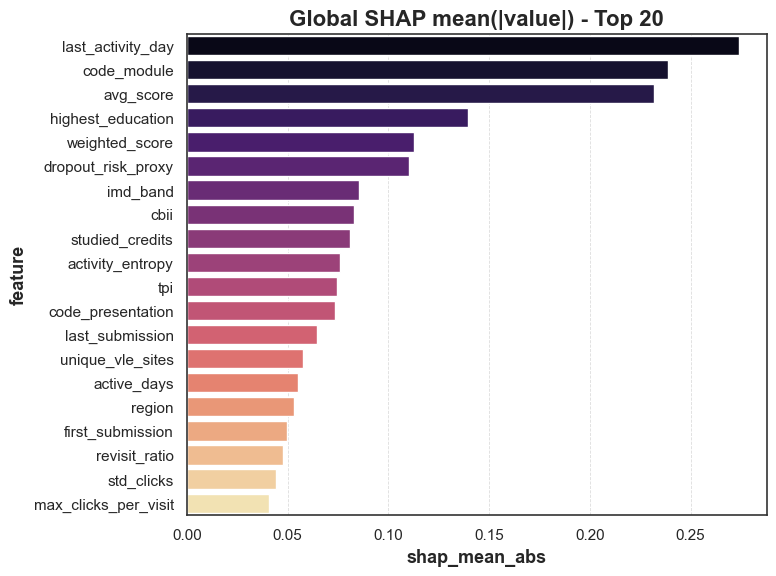

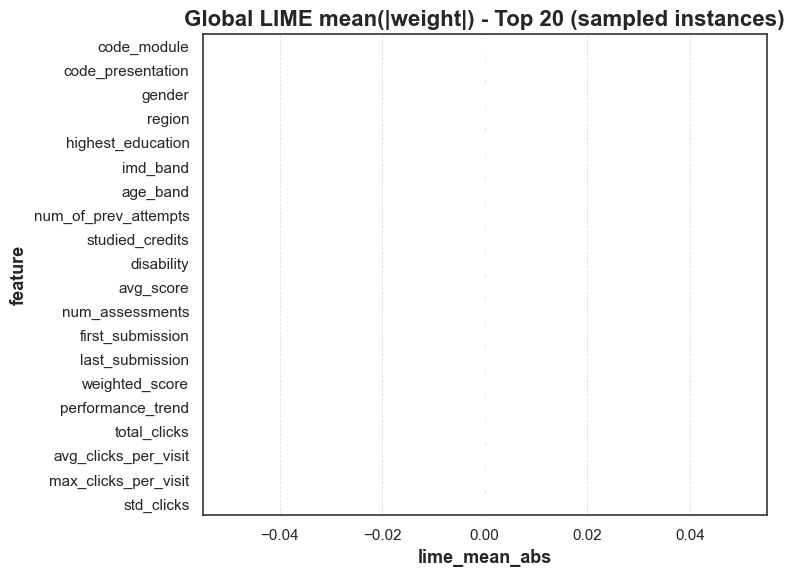

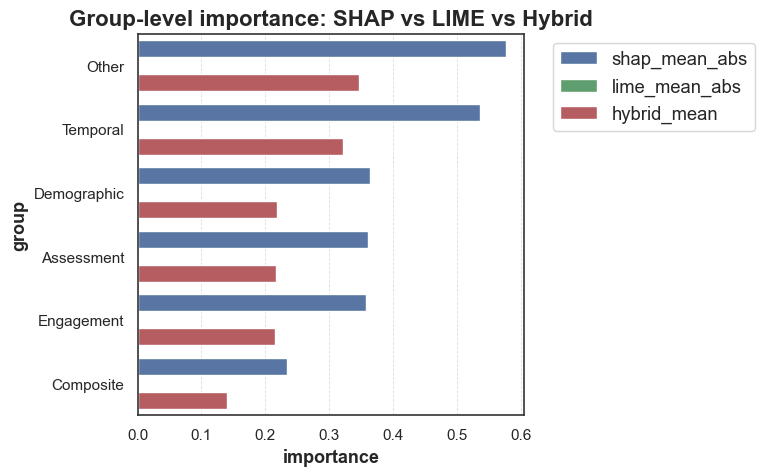

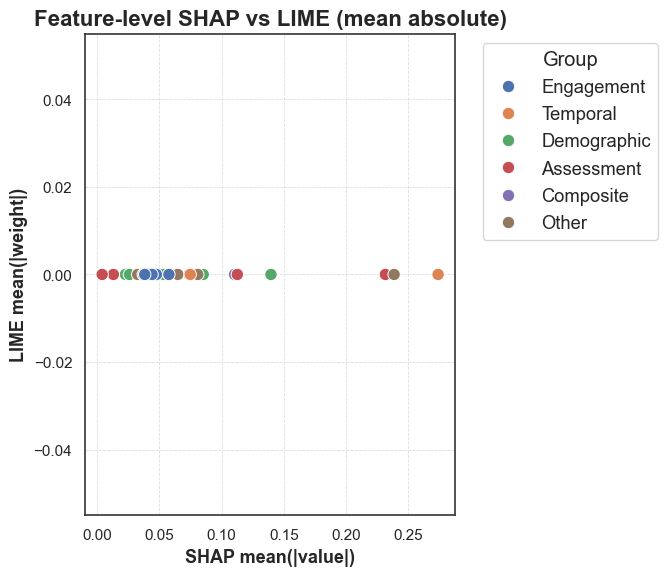


Fidelity summary (prob drop when ablating top-K):
                 count      mean       std       min       25%       50%  \
fidelity_shap     50.0  0.181485  0.206461 -0.206549  0.033901  0.170871   
fidelity_lime     50.0  0.047741  0.120064 -0.251500 -0.013636  0.036483   
fidelity_hybrid   50.0  0.193419  0.196133 -0.206549  0.053490  0.170871   

                      75%       max  
fidelity_shap    0.313085  0.596539  
fidelity_lime    0.098587  0.525341  
fidelity_hybrid  0.313085  0.596539  

Consistency summary (Spearman SHAP vs LIME):
{'mean_spearman_shap_lime': np.float64(nan), 'median_spearman_shap_lime': np.float64(nan), 'count_valid': np.int64(0)}

Efficiency (avg seconds per instance):
   method  avg_time_sec_per_instance
0    SHAP                   0.012648
1    LIME                   0.228912
2  Hybrid                   0.241560

All explainability artifacts saved in models folder

Unified explanation for sample index 9951 (pred class 2):
                   feature 

In [ ]:
print("\n--- Visualizing results ---")

plt.figure(figsize=(8,6))
sns.barplot(data=shap_global_df.head(20), x="shap_mean_abs", y="feature", palette="magma")
plt.title("Global SHAP mean(|value|) - Top 20")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
sns.barplot(data=lime_global_df.head(20), x="lime_mean_abs", y="feature", palette="viridis")
plt.title("Global LIME mean(|weight|) - Top 20 (sampled instances)")
plt.tight_layout()
plt.show()

group_level_sorted = group_level.sort_values("hybrid_mean", ascending=False)
group_level_sorted_melt = group_level_sorted.melt(id_vars="group", value_vars=["shap_mean_abs","lime_mean_abs","hybrid_mean"], var_name="method", value_name="importance")

plt.figure(figsize=(8,5))
sns.barplot(data=group_level_sorted_melt, x="importance", y="group", hue="method", palette=["#4C72B0","#55A868","#C44E52"])
plt.title("Group-level importance: SHAP vs LIME vs Hybrid")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

merged_feat_comp = pd.merge(shap_global_df, lime_global_df, on="feature", how="outer").fillna(0)
plt.figure(figsize=(7,6))
sns.scatterplot(data=merged_feat_comp, x="shap_mean_abs", y="lime_mean_abs", hue=merged_feat_comp["feature"].map(group_map), s=80)
plt.xlabel("SHAP mean(|value|)")
plt.ylabel("LIME mean(|weight|)")
plt.title("Feature-level SHAP vs LIME (mean absolute)")
plt.legend(title="Group", bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

# Fidelity summary
fidelity_summary = fidelity_df[["fidelity_shap","fidelity_lime","fidelity_hybrid"]].describe().T
print("\nFidelity summary (prob drop when ablating top-K):")
print(fidelity_summary)

print("\nConsistency summary (Spearman SHAP vs LIME):")
print(consistency_summary)

print("\nEfficiency (avg seconds per instance):")
print(efficiency_df)
shap_global_df.to_csv(os.path.join(DATA_PATH, "models", "shap_global_top.csv"), index=False)
lime_global_df.to_csv(os.path.join(DATA_PATH, "models", "lime_global_top.csv"), index=False)
group_level.to_csv(os.path.join(DATA_PATH, "models", "group_level_importance.csv"), index=False)
fidelity_df.to_csv(os.path.join(DATA_PATH, "models", "local_fidelity_by_instance.csv"), index=True)
efficiency_df.to_csv(os.path.join(DATA_PATH, "models", "explainability_timing.csv"), index=False)

print("\nAll explainability artifacts saved in models folder")

sample_idx = X_test_eval.index[0]
print(f"\nUnified explanation for sample index {sample_idx} (pred class {int(model_xgb.predict_proba(X_test.loc[[sample_idx], feature_cols])[0].argmax())}):")
unified = pd.DataFrame({
    "feature": feature_cols,
    "shap_signed": shap_local_df.loc[sample_idx, feature_cols].values,
    "lime_signed": lime_local_df.loc[sample_idx, feature_cols].values,
    "hybrid_score": hybrid_local_df.loc[sample_idx, feature_cols].values
})
unified["shap_abs"] = np.abs(unified["shap_signed"])
unified["lime_abs"] = np.abs(unified["lime_signed"])
unified = unified.sort_values("hybrid_score", ascending=False).reset_index(drop=True)
print(unified.head(15))


SHAP array shape: (2000, 34, 4)
LIME non-zero features: 34 / 34
Global feature importance (Top 10 by Hybrid):
           feature     SHAP     LIME   Hybrid
dropout_risk_proxy 0.093348 0.268520 0.664221
 last_activity_day 0.271129 0.033709 0.508691
         avg_score 0.234733 0.034016 0.440591
       code_module 0.226711 0.031718 0.420631
 highest_education 0.137773 0.032072 0.253392
    weighted_score 0.116941 0.032535 0.215014
              cbii 0.096840 0.034477 0.181113
               tpi 0.087457 0.031360 0.156869
          imd_band 0.086335 0.029555 0.150975
  activity_entropy 0.082689 0.031356 0.147854


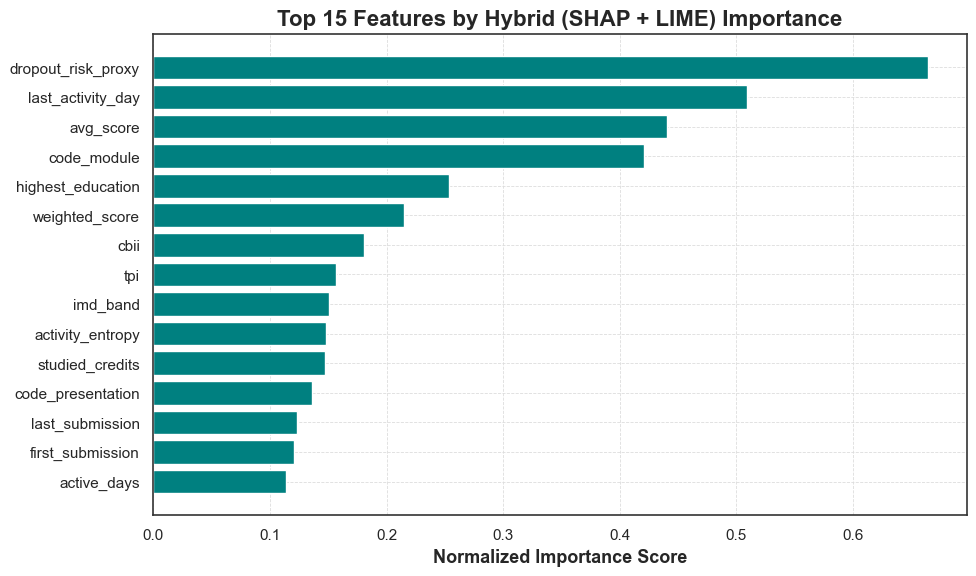

In [ ]:
if "shap_values_eval" in locals():
    _shap = shap_values_eval
elif "shap_arr" in locals():
    _shap = shap_arr
else:
    raise NameError("No SHAP array found.")

_shap = np.array(_shap)
print(f"SHAP array shape: {_shap.shape}")

if _shap.ndim == 3:
    shap_global_mean = np.abs(_shap).mean(axis=(0, 2))
else:
    shap_global_mean = np.abs(_shap).mean(axis=0)

lime_global_mean = None

if "lime_local_df" in locals() and not lime_local_df.empty:
    available_lime_cols = [c for c in feature_cols if c in lime_local_df.columns]
    if available_lime_cols:
        lime_vals = lime_local_df[available_lime_cols].abs().mean(axis=0)
        if lime_vals.sum() > 0:
            lime_global_mean = np.array([lime_vals.get(c, 0) for c in feature_cols])

if lime_global_mean is None and "lime_global_df" in locals():
    lime_map = dict(zip(lime_global_df["feature"], lime_global_df["lime_mean_abs"]))
    lime_global_mean = np.array([lime_map.get(c, 0) for c in feature_cols])

if lime_global_mean is None:
    print("Warning: LIME not available yet. Run Cell 32 first for LIME values.")
    lime_global_mean = np.zeros(len(feature_cols))

print(f"LIME non-zero features: {(lime_global_mean > 0).sum()} / {len(lime_global_mean)}")

from sklearn.preprocessing import MinMaxScaler
arr = np.vstack([shap_global_mean, lime_global_mean]).T
arr_norm = MinMaxScaler().fit_transform(arr)
hybrid_global_mean = 0.5 * arr_norm[:, 0] + 0.5 * arr_norm[:, 1]

df_global = pd.DataFrame({
    "feature": feature_cols,
    "SHAP":    shap_global_mean,
    "LIME":    lime_global_mean,
    "Hybrid":  hybrid_global_mean
}).sort_values("Hybrid", ascending=False).reset_index(drop=True)

print("Global feature importance (Top 10 by Hybrid):")
print(df_global.head(10).to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(df_global["feature"][:15], df_global["Hybrid"][:15], color="teal")
plt.gca().invert_yaxis()
plt.title("Top 15 Features by Hybrid (SHAP + LIME) Importance")
plt.xlabel("Normalized Importance Score")
plt.tight_layout()
plt.show()


In [ ]:
categorical_features = [
    i for i, c in enumerate(feature_cols)
    if X_train[c].dtype in ["int64", "object"] and X_train[c].nunique() < 20
]
continuous_features = [i for i in range(len(feature_cols)) if i not in categorical_features]

def sample_near(x_row, n_samples=500, noise_scale=0.1):
    samples = np.tile(x_row, (n_samples, 1))
    for i in continuous_features:
        std = X_train.iloc[:, i].std()
        samples[:, i] += np.random.normal(0, std * noise_scale, n_samples)
    for i in categorical_features:
        cats = X_train.iloc[:, i].unique()
        samples[:, i] = np.random.choice(cats, n_samples)
    return samples

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_cols,
    class_names=[str(c) for c in np.unique(y_train)],
    categorical_features=categorical_features,
    discretize_continuous=False,
    mode="classification"
)

def predict_fn(x):
    df = pd.DataFrame(x, columns=feature_cols)
    return model_xgb.predict_proba(df)

n_local = 200
idx_local = np.random.choice(len(X_test), n_local, replace=False)
lime_local_records = []

print(f"--- LIME: computing local explanations (distribution-aware) ---")
for idx in tqdm(idx_local):
    x_row = X_test.iloc[idx].values
    x_samples = sample_near(x_row, n_samples=600)

    y_preds = predict_fn(x_samples)
    base_pred = predict_fn([x_row])[0]
    pred_class = int(np.argmax(base_pred))

    diffs = y_preds[:, pred_class] - base_pred[pred_class]
    weights = np.corrcoef(x_samples.T, diffs)[0, 1:]
    weights = np.nan_to_num(weights)

    lime_local_records.append({
        "index": idx,
        "pred_class": pred_class,
        **dict(zip(feature_cols, weights))
    })

lime_local_df = pd.DataFrame(lime_local_records)
print(f"LIME computed for {len(lime_local_df)} instances. Shape: {lime_local_df.shape}")
print(lime_local_df.head())

--- LIME: computing local explanations (distribution-aware) ---


100%|██████████| 200/200 [00:17<00:00, 11.73it/s]

LIME computed for 200 instances. Shape: (200, 36)
   index  pred_class  code_module  code_presentation    gender    region  \
0   5250           2    -0.011147          -0.051544  0.005969 -0.012927   
1   3194           3     0.006559           0.016198  0.005999  0.001028   
2   3686           2    -0.007692           0.019570  0.035900  0.009509   
3     31           2    -0.003403           0.048736  0.025408 -0.029942   
4   1348           2     0.068187          -0.023605 -0.045910  0.042307   

   highest_education  imd_band  age_band  num_of_prev_attempts  ...  \
0           0.046134  0.004841  0.026300              0.053491  ...   
1          -0.056857  0.059042  0.017214             -0.017161  ...   
2          -0.012526  0.047011 -0.034896              0.000460  ...   
3           0.046060 -0.003985 -0.048155             -0.034638  ...   
4          -0.055521  0.029582 -0.020624             -0.033094  ...   

   revisit_ratio  study_duration  first_registration  activity_ent

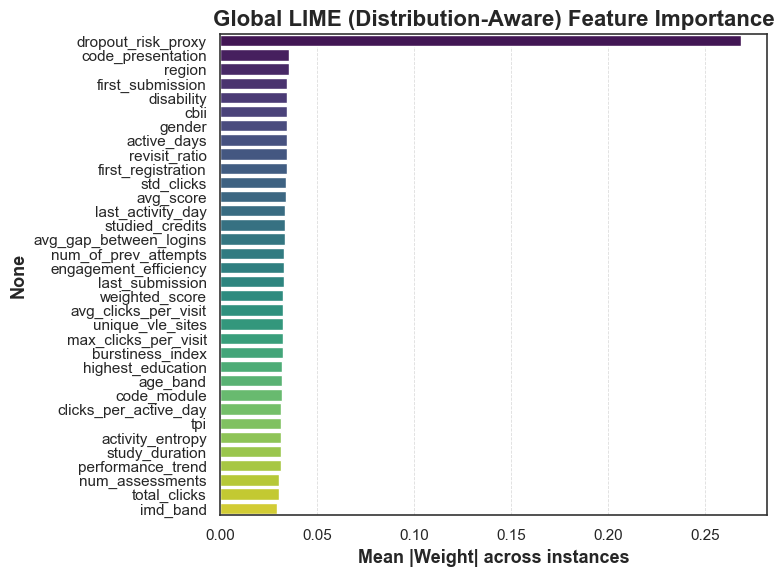

In [ ]:
lime_global_mean = lime_local_df[feature_cols].abs().mean().sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=lime_global_mean.values, y=lime_global_mean.index, palette="viridis")
plt.title("Global LIME (Distribution-Aware) Feature Importance")
plt.xlabel("Mean |Weight| across instances")
plt.tight_layout()
plt.show()



Global importance computed successfully (Top 10 by Hybrid):
              feature      SHAP      LIME    Hybrid
0  dropout_risk_proxy  0.093348  0.251165  0.664221
1   last_activity_day  0.271129  0.033023  0.508277
2           avg_score  0.234733  0.032230  0.437746
3         code_module  0.226711  0.032311  0.422778
4   highest_education  0.137773  0.032820  0.255946
5      weighted_score  0.116941  0.032429  0.215717
6                cbii  0.096840  0.032653  0.178257
7                 tpi  0.087457  0.032794  0.160854
8    activity_entropy  0.082689  0.034505  0.155705
9            imd_band  0.086335  0.030294  0.153101


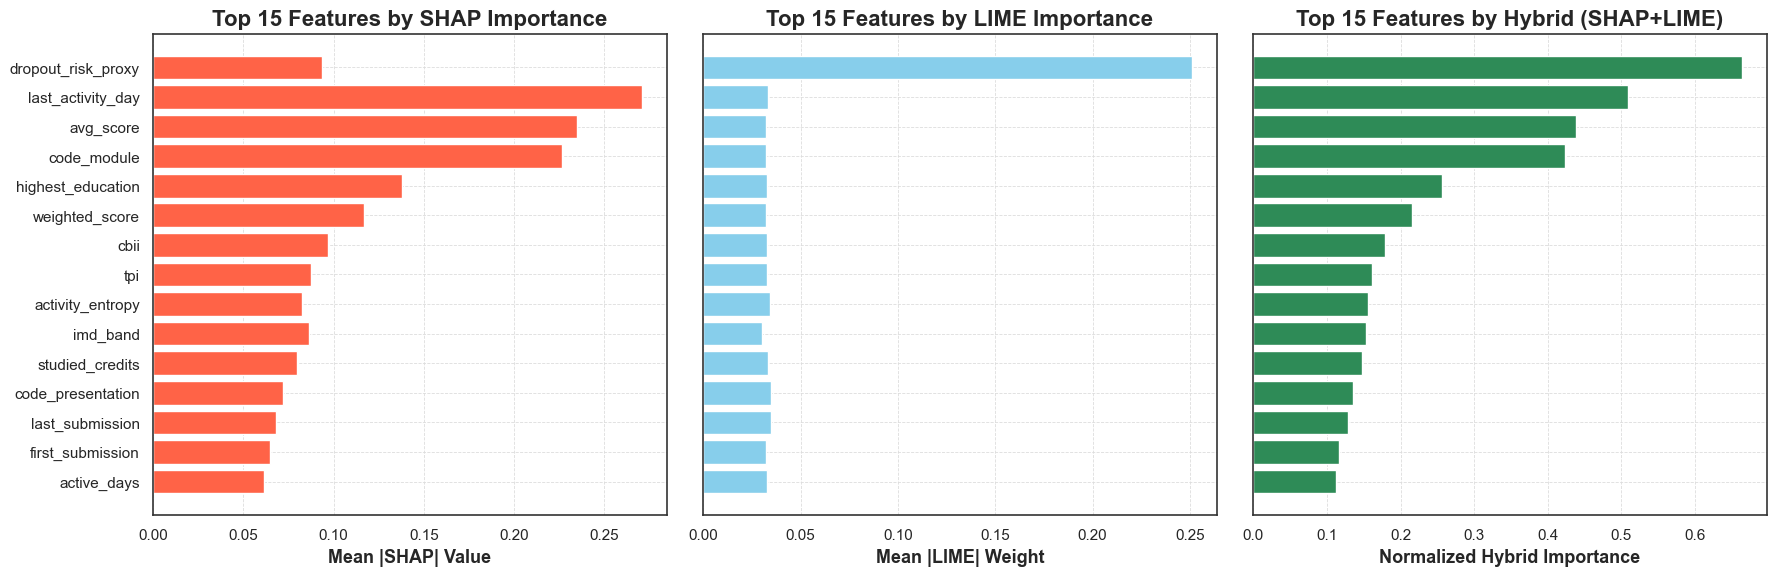

In [ ]:
if "lime_local_df" not in locals() or lime_local_df.empty:
    raise ValueError("LIME results missing. Make sure local LIME explanations were computed earlier.")

lime_local_df = lime_local_df.fillna(0)

lime_global_mean = lime_local_df[feature_cols].abs().mean(axis=0).values

if np.allclose(lime_global_mean, 0):
    print("All LIME global weights are zero — applying rescaling fallback...")
    lime_global_mean = lime_local_df[feature_cols].apply(lambda x: np.abs(x) + 1e-6).mean(axis=0).values

if "shap_values_eval" in locals():
    shap_vals_current = shap_values_eval
elif "shap_vals" in locals():
    shap_vals_current = shap_vals.values if hasattr(shap_vals, "values") else shap_vals
elif "shap_values" in locals():
    shap_vals_current = shap_values
else:
    raise NameError("No SHAP value object found. Make sure SHAP values were computed earlier.")

shap_global_mean = np.abs(shap_vals_current).mean(axis=(0, 2))

scaler = MinMaxScaler()
arr = np.vstack([shap_global_mean, lime_global_mean]).T
arr_norm = scaler.fit_transform(arr)
hybrid_global_mean = 0.5 * arr_norm[:, 0] + 0.5 * arr_norm[:, 1]

df_global = pd.DataFrame({
    "feature": feature_cols,
    "SHAP": shap_global_mean,
    "LIME": lime_global_mean,
    "Hybrid": hybrid_global_mean
}).sort_values("Hybrid", ascending=False).reset_index(drop=True)

print("\nGlobal importance computed successfully (Top 10 by Hybrid):")
print(df_global.head(10))

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

axes[0].barh(df_global["feature"][:15], df_global["SHAP"][:15], color="tomato")
axes[0].invert_yaxis()
axes[0].set_title("Top 15 Features by SHAP Importance")
axes[0].set_xlabel("Mean |SHAP| Value")

axes[1].barh(df_global["feature"][:15], df_global["LIME"][:15], color="skyblue")
axes[1].set_title("Top 15 Features by LIME Importance")
axes[1].set_xlabel("Mean |LIME| Weight")

# Hybrid
axes[2].barh(df_global["feature"][:15], df_global["Hybrid"][:15], color="seagreen")
axes[2].set_title("Top 15 Features by Hybrid (SHAP+LIME)")
axes[2].set_xlabel("Normalized Hybrid Importance")

plt.tight_layout()
plt.show()


--- Hybrid Global Importance (Adaptive) ---
  Global hybrid uses mean adaptive weight: SHAP=0.574, LIME=0.426


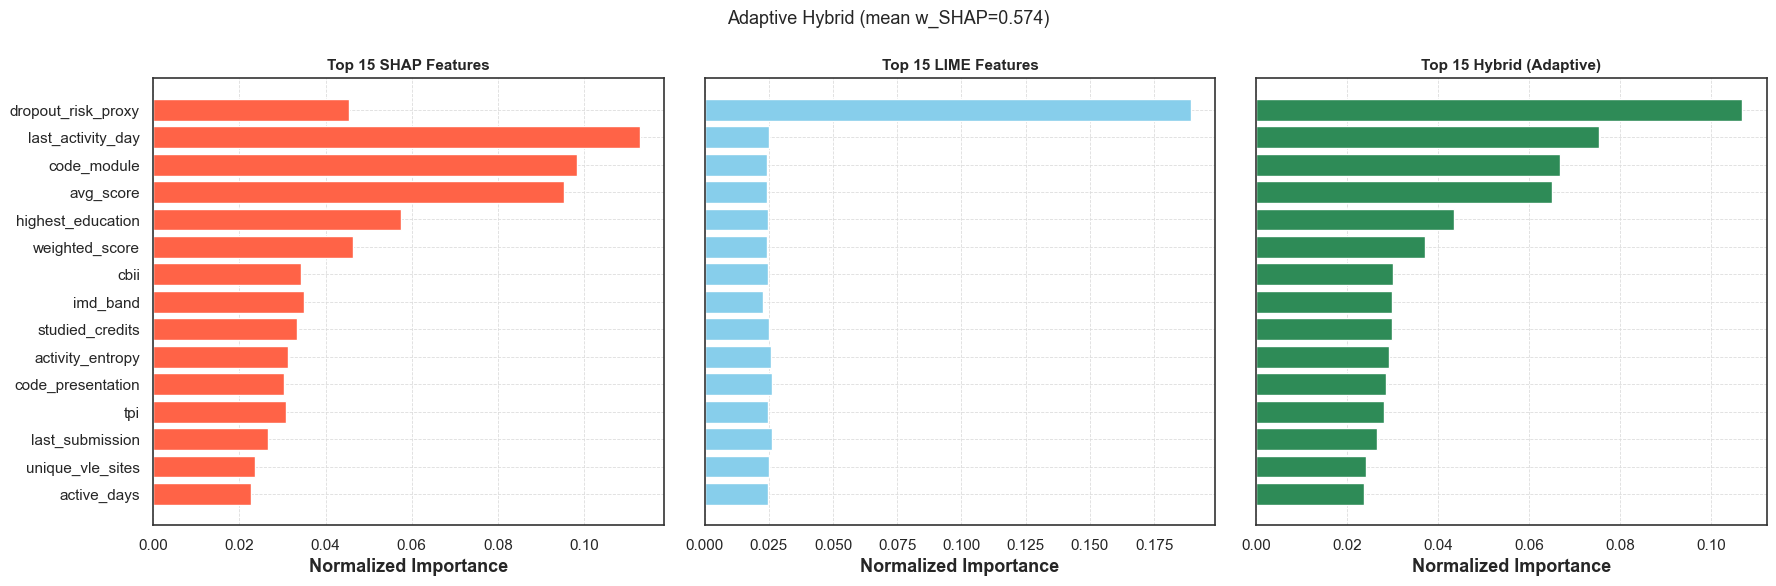


Top 10 Hybrid features:
           feature     SHAP     LIME   Hybrid
dropout_risk_proxy 0.045482 0.189389 0.106838
 last_activity_day 0.112891 0.024901 0.075375
       code_module 0.098322 0.024364 0.066789
         avg_score 0.095436 0.024302 0.065107
 highest_education 0.057525 0.024748 0.043550
    weighted_score 0.046383 0.024453 0.037033
              cbii 0.034257 0.024622 0.030149
          imd_band 0.035091 0.022843 0.029869
   studied_credits 0.033281 0.025251 0.029858
  activity_entropy 0.031375 0.026018 0.029091


In [ ]:
print("\n--- Hybrid Global Importance (Adaptive) ---")

if "shap_arr" in dir() or "shap_arr" in locals():
    _shap = shap_arr
elif "shap_vals" in locals():
    _shap = shap_vals.values if hasattr(shap_vals, "values") else shap_vals
else:
    raise NameError("No SHAP array found.")

if np.array(_shap).ndim == 3:
    shap_global_mean = np.abs(_shap).mean(axis=(0, 2))
else:
    shap_global_mean = np.abs(_shap).mean(axis=0)

lime_global_mean = lime_local_df[feature_cols].abs().mean(axis=0).values

mean_w = weights_arr.mean()  
shap_norm_g = shap_global_mean / (shap_global_mean.sum() + 1e-9)
lime_norm_g = lime_global_mean / (lime_global_mean.sum() + 1e-9)

hybrid_global_mean = mean_w * shap_norm_g + (1 - mean_w) * lime_norm_g
print(f"  Global hybrid uses mean adaptive weight: SHAP={mean_w:.3f}, LIME={1-mean_w:.3f}")

feat_imp_df = pd.DataFrame({
    "feature": feature_cols,
    "SHAP":    shap_norm_g,
    "LIME":    lime_norm_g,
    "Hybrid":  hybrid_global_mean
}).sort_values("Hybrid", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
for ax, col, color, title in zip(
    axes,
    ["SHAP","LIME","Hybrid"],
    ["tomato","skyblue","seagreen"],
    ["Top 15 SHAP Features","Top 15 LIME Features","Top 15 Hybrid (Adaptive)"]
):
    ax.barh(feat_imp_df["feature"][:15], feat_imp_df[col][:15], color=color)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Normalized Importance")

plt.suptitle(f"Adaptive Hybrid (mean w_SHAP={mean_w:.3f})", fontsize=13)
plt.tight_layout()
plt.show()

print("\nTop 10 Hybrid features:")
print(feat_imp_df[["feature","SHAP","LIME","Hybrid"]].head(10).to_string(index=False))



--- Pedagogical Mapping Layer ---


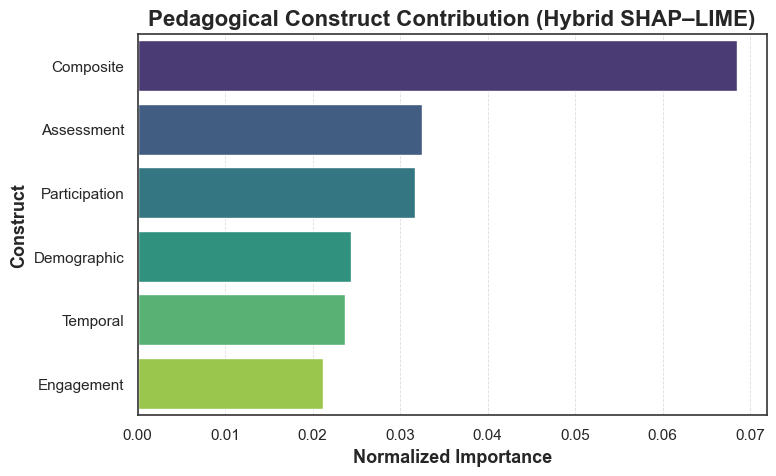

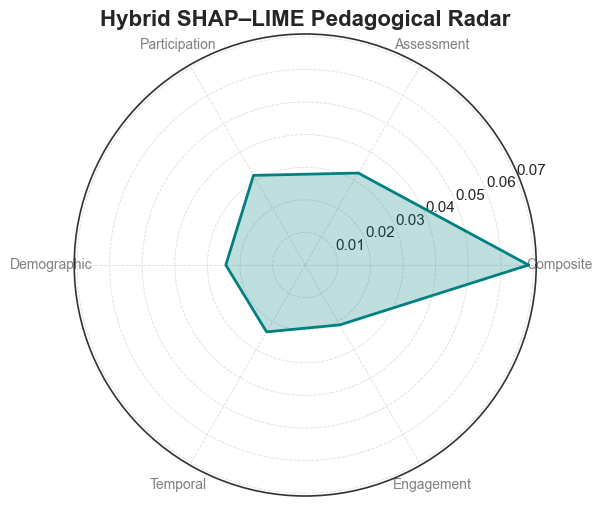

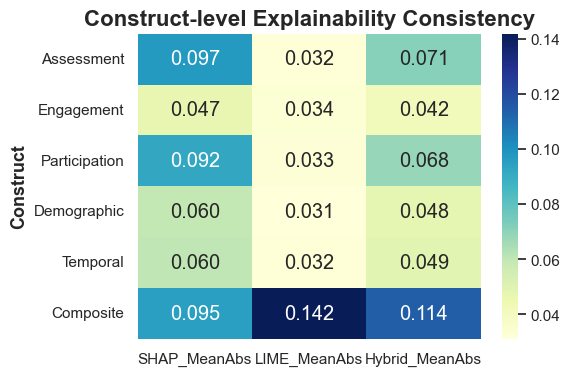


Pedagogical SHAP–LIME mapping completed.
Saved construct-level reports in models folder


In [ ]:
print("\n--- Pedagogical Mapping Layer ---")

pedagogical_map = {
    "Assessment": [
        "num_assessments", "avg_score", "weighted_score",
        "num_of_prev_attempts", "studied_credits"
    ],
    "Engagement": [
        "num_clicks", "unique_vle_sites", "avg_clicks_per_visit",
        "std_clicks", "active_days", "max_clicks_per_visit",
        "engagement_efficiency", "burstiness_index"
    ],
    "Participation": [
        "revisit_ratio", "study_duration", "last_activity_day",
        "last_submission", "avg_gap_between_logins", "tpi"
    ],
    "Demographic": [
        "gender", "region", "highest_education", "imd_band", "age_band", "disability"
    ],
    "Temporal": [
        "first_registration", "activity_entropy"
    ],
    "Composite": [
        "cbii", "dropout_risk_proxy"
    ]
}

construct_scores = {}
for construct, feats in pedagogical_map.items():
    valid_feats = [f for f in feats if f in feat_imp_df["feature"].values]
    if not valid_feats:
        continue
    mean_score = feat_imp_df.set_index("feature").loc[valid_feats, "Hybrid"].mean()
    construct_scores[construct] = mean_score

pedagogical_df = (
    pd.DataFrame.from_dict(construct_scores, orient="index", columns=["Hybrid_Importance"])
    .sort_values("Hybrid_Importance", ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(x=pedagogical_df["Hybrid_Importance"], y=pedagogical_df.index, palette="viridis")
plt.title("Pedagogical Construct Contribution (Hybrid SHAP–LIME)")
plt.xlabel("Normalized Importance")
plt.ylabel("Construct")
plt.tight_layout()
plt.show()

constructs = pedagogical_df.index.tolist()
values = pedagogical_df["Hybrid_Importance"].values
values = np.append(values, values[0])  # close loop

angles = [n / float(len(constructs)) * 2 * pi for n in range(len(constructs))]
angles += angles[:1]

plt.figure(figsize=(6, 6))
ax = plt.subplot(111, polar=True)
plt.xticks(angles[:-1], constructs, color='grey', size=10)
ax.plot(angles, values, linewidth=2, linestyle='solid', color='teal')
ax.fill(angles, values, color='teal', alpha=0.25)
plt.title("Hybrid SHAP–LIME Pedagogical Radar")
plt.show()

if hasattr(shap_vals, "values"):
    shap_arr = shap_vals.values
else:
    shap_arr = shap_vals

shap_cons, lime_cons = {}, {}
for construct, feats in pedagogical_map.items():
    feats = [f for f in feats if f in feature_cols]
    if not feats:
        shap_cons[construct], lime_cons[construct] = 0, 0
        continue

    feat_idx = [feature_cols.index(f) for f in feats]
    if shap_arr.ndim == 3:
        shap_cons[construct] = np.abs(shap_arr[:, feat_idx, :]).mean()
    else:
        shap_cons[construct] = np.abs(shap_arr[:, feat_idx]).mean()

    lime_cons[construct] = lime_local_df[feats].abs().mean().mean()

pedagogical_consistency_df = pd.DataFrame({
    "Construct": list(pedagogical_map.keys()),
    "SHAP_MeanAbs": [shap_cons[c] for c in pedagogical_map.keys()],
    "LIME_MeanAbs": [lime_cons[c] for c in pedagogical_map.keys()]
})
pedagogical_consistency_df["Hybrid_MeanAbs"] = (
    0.6 * pedagogical_consistency_df["SHAP_MeanAbs"] +
    0.4 * pedagogical_consistency_df["LIME_MeanAbs"]
)

plt.figure(figsize=(6, 4))
sns.heatmap(
    pedagogical_consistency_df.set_index("Construct")[["SHAP_MeanAbs", "LIME_MeanAbs", "Hybrid_MeanAbs"]],
    cmap="YlGnBu", annot=True, fmt=".3f"
)
plt.title("Construct-level Explainability Consistency")
plt.tight_layout()
plt.show()

pedagogical_df.to_csv(os.path.join(DATA_PATH, "models", "pedagogical_construct_importance.csv"), index=True)
pedagogical_consistency_df.to_csv(os.path.join(DATA_PATH, "models", "pedagogical_construct_consistency.csv"), index=False)

print("\nPedagogical SHAP–LIME mapping completed.")
print("Saved construct-level reports in models folder")


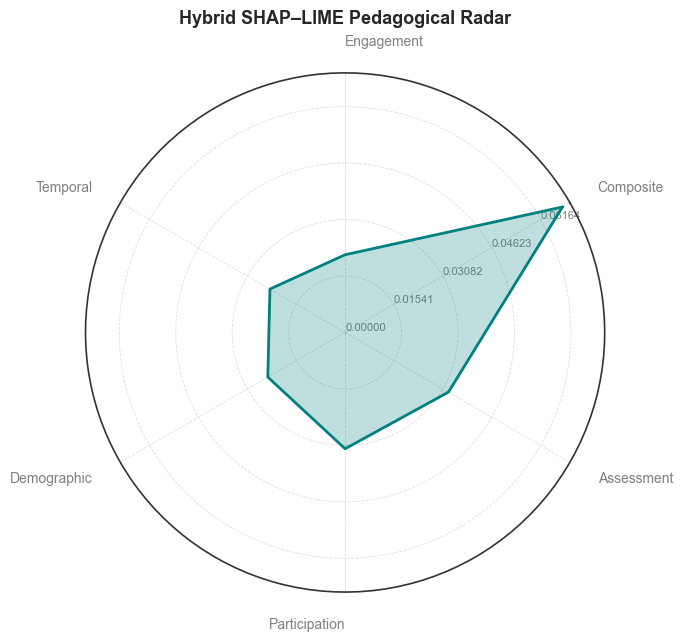

In [ ]:
constructs = pedagogical_df.index.tolist()
values = pedagogical_df["Hybrid_Importance"].values
values = np.append(values, values[0])  

N = len(constructs)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]
rotation_offset = pi / N 

plt.figure(figsize=(7, 7))
ax = plt.subplot(111, polar=True)
ax.set_theta_offset(rotation_offset)
ax.set_theta_direction(-1)

plt.xticks(angles[:-1], constructs, color='grey', size=10)
ax.tick_params(axis='x', pad=10) 
for label, angle in zip(ax.get_xticklabels(), angles):
    angle_deg = np.degrees(angle)
    if angle_deg > 90 and angle_deg < 270:
        label.set_horizontalalignment('right')
        label.set_rotation(angle_deg + 90)
    else:
        label.set_horizontalalignment('left')
        label.set_rotation(angle_deg - 90)

ax.plot(angles, values, linewidth=2, linestyle='solid', color='teal')
ax.fill(angles, values, color='teal', alpha=0.25)

# Style
plt.title("Hybrid SHAP–LIME Pedagogical Radar", size=13, y=1.08)
ax.set_rlabel_position(0)
plt.yticks(np.linspace(0, max(values)*0.9, 5), color="grey", size=8)
plt.tight_layout()
plt.show()


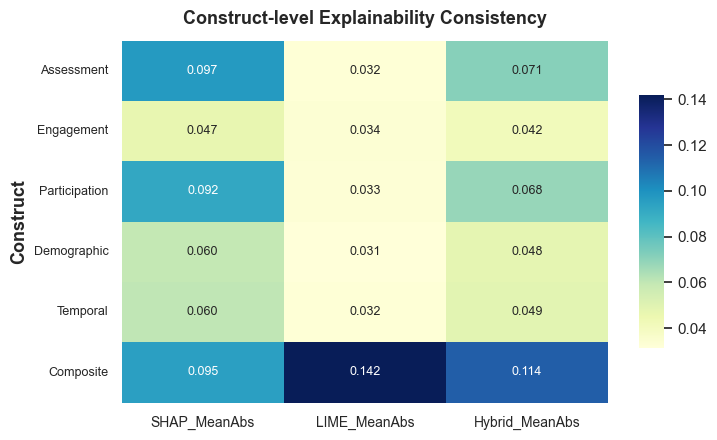

In [ ]:
plt.figure(figsize=(8, 5))  
sns.heatmap(
    pedagogical_consistency_df.set_index("Construct")[["SHAP_MeanAbs", "LIME_MeanAbs", "Hybrid_MeanAbs"]],
    cmap="YlGnBu",
    annot=True,
    fmt=".3f",
    annot_kws={"size":9},
    cbar_kws={"shrink": 0.7, "aspect": 10}
)

plt.title("Construct-level Explainability Consistency", fontsize=13, pad=12)

plt.xticks(rotation=0, ha='center', fontsize=10)
plt.yticks(rotation=0, ha='right', fontsize=9)

plt.tight_layout(pad=2)
plt.show()


In [ ]:
DATA_PREP_CSV = os.path.join(DATA_PATH, "oulad_preprocessed_noleak.csv")  
STUDENT_VLE_CSV = os.path.join(DATA_PATH, "studentVle.csv")  
SEQUENCE_LENGTH = 30 
BATCH_SIZE = 256
EPOCHS = 60
LR = 3e-4
WEIGHT_DECAY = 1e-5
D_MODEL = 128
N_HEADS = 4
N_LAYERS = 3
D_FF = 256
DROPOUT = 0.1
AUX_LOSS_WEIGHT = 0.3
RANDOM_SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR = os.path.join(DATA_PATH, "models_htbt")
os.makedirs(OUTPUT_DIR, exist_ok=True)

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

In [ ]:
import os

search_path = r"C:\Users\acer\Desktop\PhD materials"
target_file = "oulad_preprocessed_noleak.csv"

found = False
for root, dirs, files in os.walk(search_path):
    if target_file in files:
        print(f"✅ File found! The correct path is: \n{os.path.join(root, target_file)}")
        found = True
        break

if not found:
    print("❌ File not found. Please check the search path and filename.")

print(DATA_PREP_CSV)

✅ وجدته! المسار الصحيح هو: 
C:\Users\acer\Desktop\PhD materials\Manuscripts\DataSets\anonymisedData\oulad_preprocessed_noleak.csv
C:\Users\acer\Desktop\PhD materials\Manuscripts\DataSets\anonymisedData\oulad_preprocessed_noleak.csv


In [ ]:
df = pd.read_csv(DATA_PREP_CSV)
print('Loaded preprocessed: ', df.shape)

if 'target_result' in df.columns:
    target_col = 'target_result'
else:
    raise ValueError('target_result column missing')

id_cols    = ['id_student', 'code_module', 'code_presentation']
leaky_cols = ['date_unregistration', 'final_result']  
meta_df    = df[id_cols + [target_col]].copy()

drop_cols      = id_cols + [target_col] + [c for c in leaky_cols if c in df.columns]
static_features = [c for c in df.columns if c not in drop_cols]

print('Number of static features:', len(static_features))
print('Leaky cols found and removed:', [c for c in leaky_cols if c in df.columns])

X_static = df[static_features].fillna(0).reset_index(drop=True)
y        = df[target_col].astype(int).values


Loaded preprocessed:  (32593, 37)
Number of static features: 32
Leaky cols found and removed: ['final_result']


In [ ]:

SEQUENCE_LENGTH = 30
CUTOFF_DAY      = 30   

vle = pd.read_csv(STUDENT_VLE_CSV)
vle['date'] = pd.to_numeric(vle['date'], errors='coerce').fillna(0).astype(int)

vle_cut = vle[vle['date'] <= CUTOFF_DAY].copy()
print(f'VLE records  before cutoff : {len(vle)}')
print(f'VLE records  after  cutoff : {len(vle_cut)}  (day <= {CUTOFF_DAY})')

meta_df['key'] = (
    meta_df['id_student'].astype(str) + '_' +
    meta_df['code_module'].astype(str) + '_' +
    meta_df['code_presentation'].astype(str)
)
vle_cut['key'] = (
    vle_cut['id_student'].astype(str) + '_' +
    vle_cut['code_module'].astype(str) + '_' +
    vle_cut['code_presentation'].astype(str)
)

vle_day = (
    vle_cut.groupby(['key', 'date'], as_index=False)['sum_click']
    .sum()
    .sort_values(['key', 'date'])
)

keys        = meta_df['key'].unique()
key_to_idx  = {k: i for i, k in enumerate(keys)}
num_keys    = len(keys)

sequences = np.zeros((num_keys, SEQUENCE_LENGTH), dtype=np.float32)

for row in vle_day.itertuples(index=False):
    if row.key in key_to_idx:
        day_idx = int(row.date)
        if 0 <= day_idx < SEQUENCE_LENGTH:
            sequences[key_to_idx[row.key], day_idx] = row.sum_click

sequences = np.log1p(sequences)

print(f'Sequences built : {sequences.shape}')
print(f'Non-zero entries: {(sequences > 0).sum()} '
      f'({100*(sequences>0).mean():.1f}% of all positions)')


VLE records  before cutoff : 10655280
VLE records  after  cutoff : 2980575  (day <= 30)
Sequences built : (32593, 30)
Non-zero entries: 319538 (32.7% of all positions)


In [ ]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

y_array = y.astype(np.int64)

train_val_idx, test_idx = train_test_split(
    np.arange(len(y_array)),
    test_size=0.20,
    stratify=y_array,
    random_state=RANDOM_SEED
)
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.20,
    stratify=y_array[train_val_idx],
    random_state=RANDOM_SEED
)

X_static_encoded = X_static.copy()
cat_cols = X_static_encoded.select_dtypes(include='object').columns.tolist()

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    le.fit(X_static_encoded.iloc[train_idx][col].astype(str))
    classes_set = set(le.classes_)
    X_static_encoded[col] = X_static_encoded[col].astype(str).apply(
        lambda x: int(le.transform([x])[0]) if x in classes_set else -1
    )
    le_dict[col] = le

print(f'Categorical cols encoded on train only: {cat_cols}')

scaler_htbt = StandardScaler()
X_enc_arr    = X_static_encoded.values.astype(np.float32)

X_train_scaled = scaler_htbt.fit_transform(X_enc_arr[train_idx])
X_val_scaled   = scaler_htbt.transform(X_enc_arr[val_idx])
X_test_scaled  = scaler_htbt.transform(X_enc_arr[test_idx])

X_scaled = np.zeros_like(X_enc_arr)
X_scaled[train_idx] = X_train_scaled
X_scaled[val_idx]   = X_val_scaled
X_scaled[test_idx]  = X_test_scaled

print(f'Static features scaled on train only. Shape: {X_scaled.shape}')

class HTBTDataset(Dataset):
    def __init__(self, X_static, sequences, y):
        self.X   = X_static.astype(np.float32)
        self.seq = sequences.astype(np.float32)
        self.y   = y.astype(np.int64)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return {
            'static': torch.from_numpy(self.X[idx]),
            'seq'   : torch.from_numpy(self.seq[idx]),
            'y'     : torch.tensor(int(self.y[idx]), dtype=torch.long)
        }


BATCH_SIZE = 64

train_ds = HTBTDataset(X_scaled[train_idx], sequences[train_idx], y_array[train_idx])
val_ds   = HTBTDataset(X_scaled[val_idx],   sequences[val_idx],   y_array[val_idx])
test_ds  = HTBTDataset(X_scaled[test_idx],  sequences[test_idx],  y_array[test_idx])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

num_classes = len(np.unique(y_array))

print('Train / Val / Test sizes:', len(train_ds), len(val_ds), len(test_ds))
print('Num classes            :', num_classes)
print('Static features shape  :', train_ds.X.shape)
print('Sequence shape         :', train_ds.seq.shape)


Categorical cols encoded on train only: ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']
Static features scaled on train only. Shape: (32593, 32)
Train / Val / Test sizes: 20859 5215 6519
Num classes            : 4
Static features shape  : (20859, 32)
Sequence shape         : (20859, 30)


In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0) 
        self.register_buffer('pe', pe)
    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :].to(x.dtype)
        return x

class HTBT(nn.Module):
    def __init__(self, n_static, seq_len, d_model=128, n_heads=4, n_layers=3, d_ff=256, dropout=0.1, num_classes=4):
        super().__init__()
        self.seq_len = seq_len
        self.seq_proj = nn.Sequential(
            nn.Linear(1, d_model),
            nn.ReLU(),
            nn.LayerNorm(d_model)
        )
        self.pos_enc = PositionalEncoding(d_model, max_len=seq_len+10)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_heads, dim_feedforward=d_ff, dropout=dropout, batch_first=True)
        self.seq_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.static_proj = nn.Sequential(
            nn.Linear(n_static, d_model),
            nn.ReLU(),
            nn.LayerNorm(d_model)
        )
        self.cross_attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=n_heads, dropout=dropout, batch_first=True)
        # Fusion + classifier
        self.fusion_mlp = nn.Sequential(
            nn.Linear(d_model*2, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.LayerNorm(d_ff),
            nn.Linear(d_ff, d_model),
            nn.ReLU()
        )
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_ff//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff//2, num_classes)
        )
        self.attn_weights = None
    def forward(self, static_x, seq_x):
        B = static_x.size(0)
        seq = seq_x.unsqueeze(-1)  
        seq = self.seq_proj(seq)   
        seq = self.pos_enc(seq)
        seq_enc = self.seq_encoder(seq) 
        seq_pool = seq_enc.mean(dim=1)  
        static_emb = self.static_proj(static_x)  
        q = static_emb.unsqueeze(1) 
        k = seq_enc  
        v = seq_enc
        attn_out, attn_weights = self.cross_attn(query=q, key=k, value=v, need_weights=True, average_attn_weights=False)
        attn_out = attn_out.squeeze(1) 
        self.attn_weights = attn_weights 
        fused = torch.cat([static_emb, attn_out], dim=-1)
        fused = self.fusion_mlp(fused) 
        logits = self.classifier(fused)  
        return logits, seq_pool, static_emb

In [ ]:
os.makedirs(os.path.join(DATA_PATH, 'models'), exist_ok=True)
os.makedirs(os.path.join(DATA_PATH, 'models_htbt'), exist_ok=True)

model = HTBT(n_static=X_static.shape[1], seq_len=SEQUENCE_LENGTH, d_model=D_MODEL, n_heads=N_HEADS, n_layers=N_LAYERS, d_ff=D_FF, dropout=DROPOUT, num_classes=num_classes)
model = model.to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

def calc_metrics(y_true, y_pred, y_prob=None):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    auc = None
    if y_prob is not None and y_prob.shape[1] == num_classes:
        try:
            auc = roc_auc_score(pd.get_dummies(y_true), y_prob, average="macro", multi_class="ovr")
        except Exception:
            auc = None
    return {"acc": acc, "f1": f1, "prec": prec, "rec": rec, "auc": auc}

best_val = -1e9
patience = 8
patience_counter = 0

for epoch in range(1, EPOCHS+1):
    model.train()
    train_loss = 0.0
    n_train = 0
    for batch in train_loader:
        static = batch["static"].to(DEVICE)
        seq = batch["seq"].to(DEVICE)
        labels = batch["y"].to(DEVICE)
        optimizer.zero_grad()
        logits, seq_pool, static_emb = model(static, seq)
        ce = criterion(logits, labels)
        mse = nn.functional.mse_loss(seq_pool, static_emb)
        loss = ce + AUX_LOSS_WEIGHT * mse
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * static.size(0)
        n_train += static.size(0)
    scheduler.step()
    train_loss /= max(1, n_train)

    model.eval()
    y_trues = []
    y_preds = []
    y_probs = []
    val_loss = 0.0
    n_val = 0
    with torch.no_grad():
        for batch in val_loader:
            static = batch["static"].to(DEVICE)
            seq = batch["seq"].to(DEVICE)
            labels = batch["y"].to(DEVICE)
            logits, seq_pool, static_emb = model(static, seq)
            ce = criterion(logits, labels)
            mse = nn.functional.mse_loss(seq_pool, static_emb)
            loss = ce + AUX_LOSS_WEIGHT * mse
            val_loss += loss.item() * static.size(0)
            n_val += static.size(0)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)
            y_trues.extend(labels.cpu().numpy().tolist())
            y_preds.extend(preds.tolist())
            y_probs.extend(probs.tolist())
    val_loss /= max(1, n_val)
    metrics = calc_metrics(y_trues, y_preds, np.array(y_probs))
    print(f"Epoch {epoch:02d} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | val_acc {metrics['acc']:.4f} val_f1 {metrics['f1']:.4f} val_auc {metrics['auc']:.4f}")
    score = metrics["f1"]
    if score > best_val:
        best_val = score
        patience_counter = 0
        torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "htbt_best.pt"))
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered")
            break

Epoch 01 | train_loss 1.2636 | val_loss 1.1967 | val_acc 0.5542 val_f1 0.3813 val_auc 0.7535
Epoch 02 | train_loss 1.1434 | val_loss 1.1372 | val_acc 0.5523 val_f1 0.3903 val_auc 0.7604
Epoch 03 | train_loss 1.0978 | val_loss 1.1069 | val_acc 0.5607 val_f1 0.4097 val_auc 0.7676
Epoch 04 | train_loss 1.0709 | val_loss 1.0951 | val_acc 0.5515 val_f1 0.4553 val_auc 0.7685
Epoch 05 | train_loss 1.0509 | val_loss 1.0955 | val_acc 0.5534 val_f1 0.3873 val_auc 0.7660
Epoch 06 | train_loss 1.0351 | val_loss 1.0760 | val_acc 0.5584 val_f1 0.4514 val_auc 0.7691
Epoch 07 | train_loss 1.0214 | val_loss 1.0615 | val_acc 0.5618 val_f1 0.4143 val_auc 0.7702
Epoch 08 | train_loss 1.0137 | val_loss 1.0618 | val_acc 0.5605 val_f1 0.4066 val_auc 0.7701
Epoch 09 | train_loss 1.0040 | val_loss 1.0594 | val_acc 0.5588 val_f1 0.4114 val_auc 0.7661
Epoch 10 | train_loss 0.9954 | val_loss 1.0663 | val_acc 0.5563 val_f1 0.4241 val_auc 0.7669
Epoch 11 | train_loss 0.9841 | val_loss 1.0676 | val_acc 0.5584 val_f1

Loading best model and evaluating on test set...
Test metrics: {'acc': 0.5652707470470931, 'f1': 0.47991087549911715, 'prec': 0.5342997370535161, 'rec': 0.4694188204295975, 'auc': 0.7797520535231997}
Attention matrix shape (batches concatenated) approx: (6519, 30)


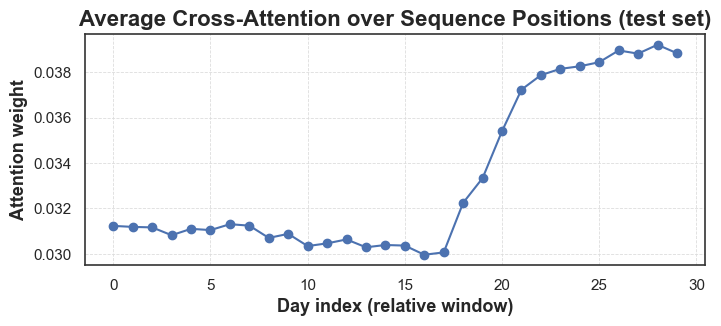

Model, preds, metrics saved under C:\Users\acer\Desktop\PhD materials\Manuscripts\DataSets\anonymisedData\models_htbt


In [ ]:
print("Loading best model and evaluating on test set...")
model.load_state_dict(torch.load(os.path.join(OUTPUT_DIR, "htbt_best.pt")))
model.eval()
y_trues = []
y_preds = []
y_probs = []
attn_store = []

with torch.no_grad():
    for batch in test_loader:
        static = batch["static"].to(DEVICE)
        seq = batch["seq"].to(DEVICE)
        labels = batch["y"].to(DEVICE)

        logits, seq_pool, static_emb = model(static, seq)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

        y_trues.extend(labels.cpu().numpy().tolist())
        y_preds.extend(preds.tolist())
        y_probs.extend(probs.tolist())

        attn = model.attn_weights 
        if attn is not None:
            attn_np = attn.cpu().numpy()
            attn_avg_heads = attn_np.mean(axis=1) 

            if attn_avg_heads.ndim == 3 and attn_avg_heads.shape[1] == 1:
                attn_avg = attn_avg_heads.squeeze(1)  
            elif attn_avg_heads.ndim == 2:
                attn_avg = attn_avg_heads   
            else:
                attn_avg = attn_avg_heads.mean(axis=1) 

            attn_store.append(attn_avg)

metrics_test = calc_metrics(y_trues, y_preds, np.array(y_probs))
print("Test metrics:", metrics_test)

if len(attn_store) > 0:
    attn_mat = np.vstack(attn_store) 
    print("Attention matrix shape (batches concatenated) approx:", attn_mat.shape)

    avg_attn = attn_mat.mean(axis=0)
    plt.figure(figsize=(8,3))
    plt.plot(np.arange(SEQUENCE_LENGTH), avg_attn, marker='o')
    plt.title("Average Cross-Attention over Sequence Positions (test set)")
    plt.xlabel("Day index (relative window)")
    plt.ylabel("Attention weight")
    plt.grid(True)
    plt.show()

out_df = pd.DataFrame({
    "y_true": y_trues,
    "y_pred": y_preds,
})
out_df.to_csv(os.path.join(OUTPUT_DIR, "htbt_test_preds.csv"), index=False)
pd.DataFrame([metrics_test]).to_csv(os.path.join(OUTPUT_DIR, "htbt_test_metrics.csv"), index=False)

print("Model, preds, metrics saved under", OUTPUT_DIR)


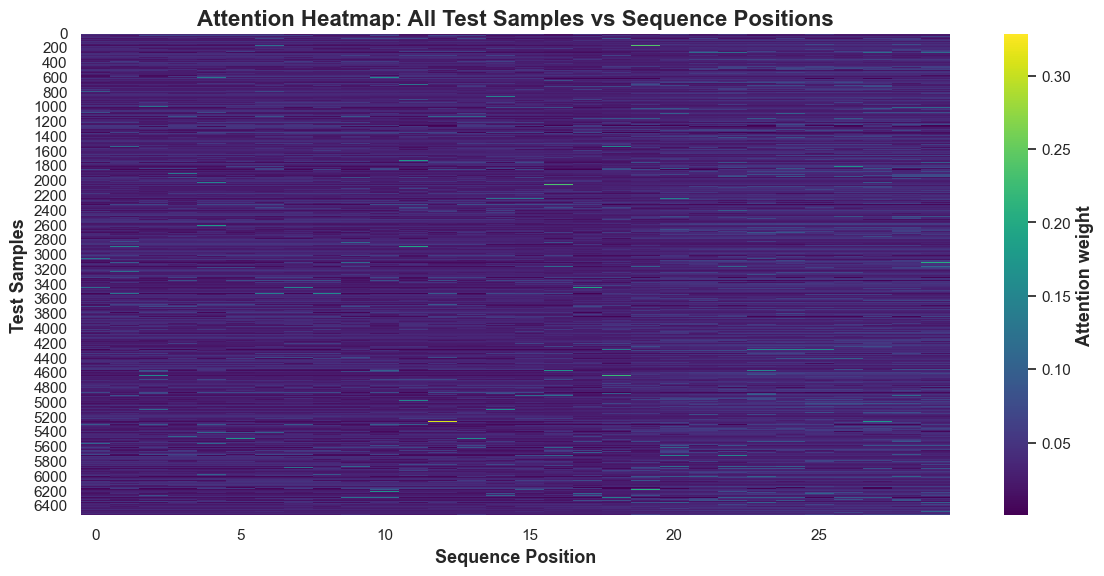

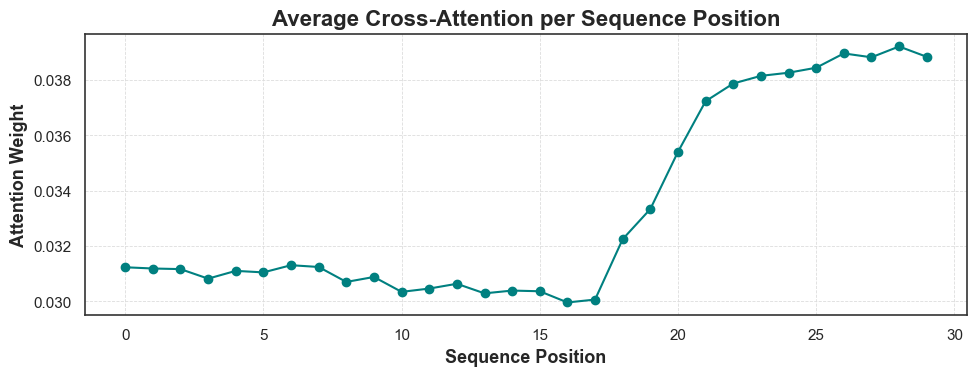

Cluster counts: [2462 2108 1949]


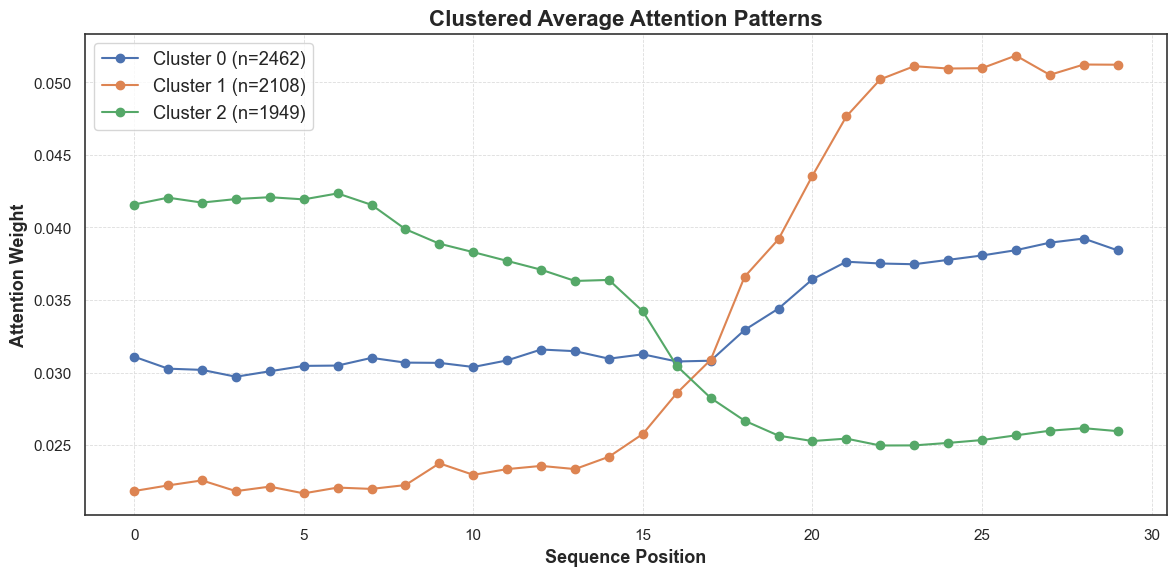

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(attn_mat, cmap="viridis", xticklabels=5, yticklabels=200, cbar_kws={'label': 'Attention weight'})
plt.xlabel("Sequence Position")
plt.ylabel("Test Samples")
plt.title("Attention Heatmap: All Test Samples vs Sequence Positions")
plt.tight_layout()
plt.show()

avg_attn = attn_mat.mean(axis=0)
plt.figure(figsize=(10,4))
plt.plot(np.arange(SEQUENCE_LENGTH), avg_attn, marker='o', linestyle='-', color='teal')
plt.title("Average Cross-Attention per Sequence Position")
plt.xlabel("Sequence Position")
plt.ylabel("Attention Weight")
plt.grid(True)
plt.tight_layout()
plt.show()

scaler = StandardScaler()
attn_scaled = scaler.fit_transform(attn_mat)

n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(attn_scaled)

print(f"Cluster counts: {np.bincount(clusters)}")

plt.figure(figsize=(12, 6))
for c in range(n_clusters):
    cluster_idx = np.where(clusters == c)[0]
    cluster_avg = attn_mat[cluster_idx].mean(axis=0)
    plt.plot(np.arange(SEQUENCE_LENGTH), cluster_avg, marker='o', label=f'Cluster {c} (n={len(cluster_idx)})')

plt.title("Clustered Average Attention Patterns")
plt.xlabel("Sequence Position")
plt.ylabel("Attention Weight")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


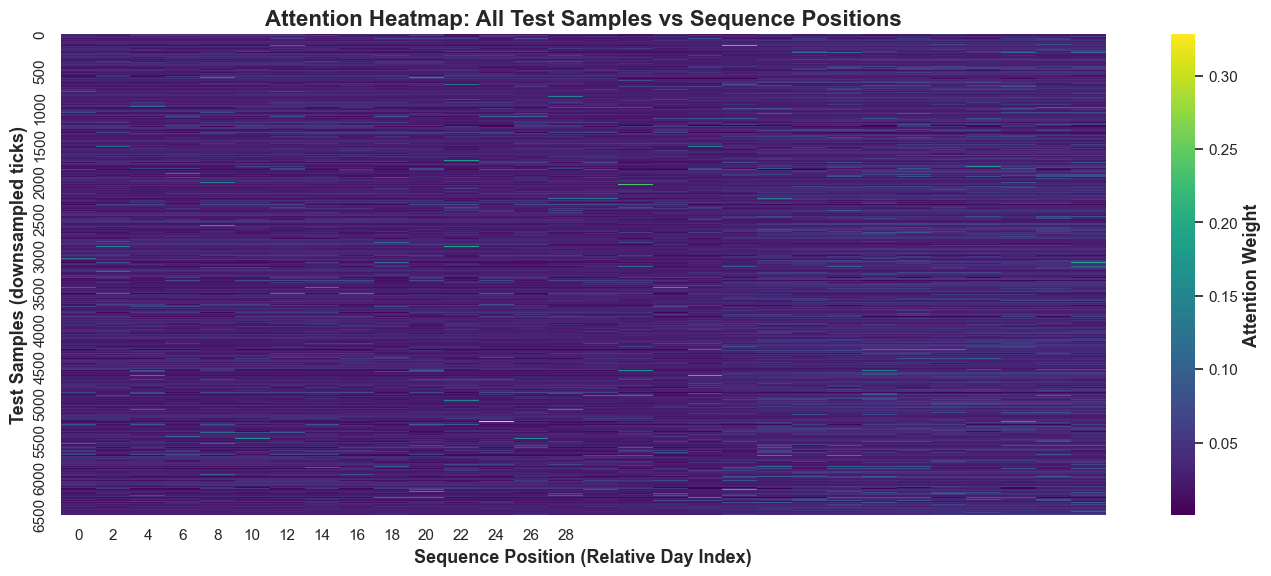

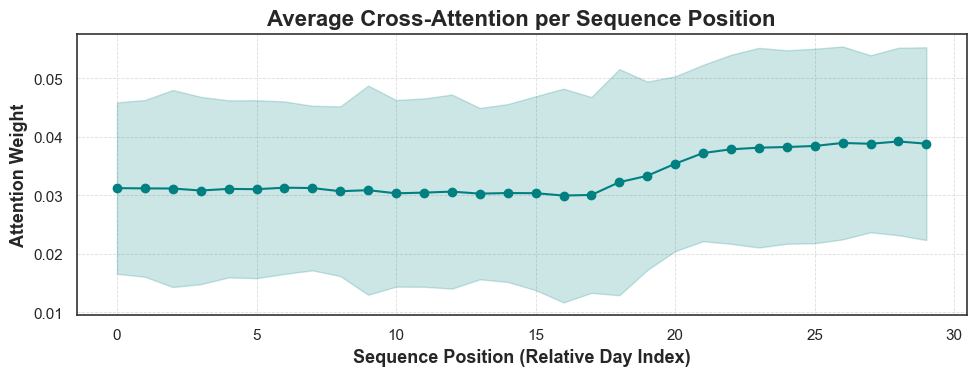

Top 3 attended sequence positions: [28 26 29], weights: [0.03920758 0.03895659 0.03883452]
Lowest 3 attended sequence positions: [16 17 13], weights: [0.02996396 0.03006784 0.03029256]
Cluster counts: Cluster
0    2462
1    2108
2    1949
Name: count, dtype: int64


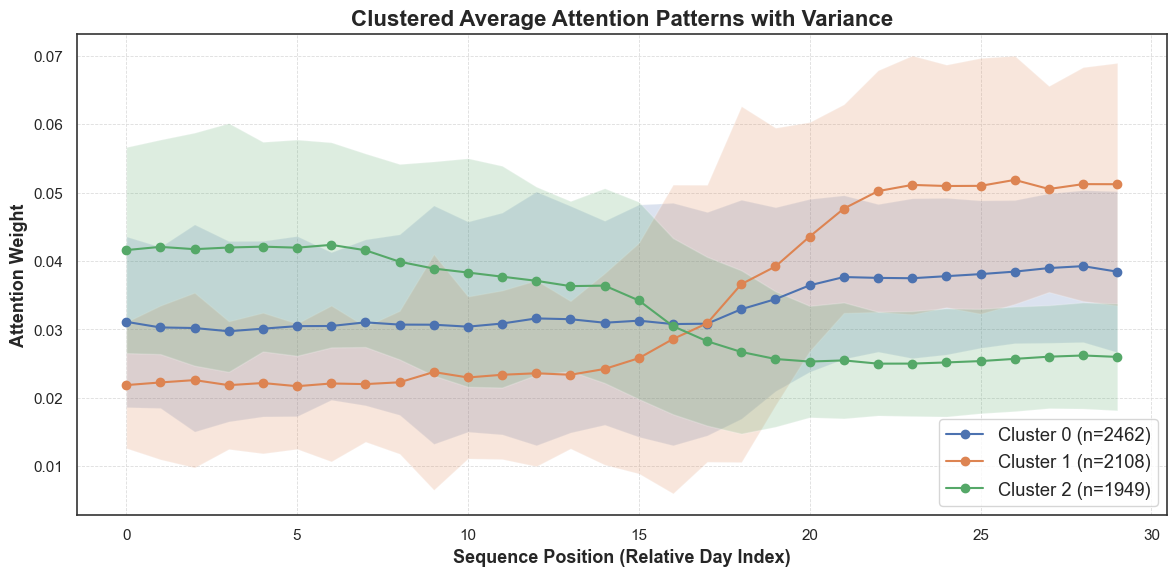

In [ ]:
plt.figure(figsize=(14, 6))
sns.heatmap(
    attn_mat,
    cmap="viridis",
    xticklabels=range(0, SEQUENCE_LENGTH, 2),
    yticklabels=500, 
    cbar_kws={'label': 'Attention Weight'}
)
plt.xlabel("Sequence Position (Relative Day Index)")
plt.ylabel("Test Samples (downsampled ticks)")
plt.title("Attention Heatmap: All Test Samples vs Sequence Positions")
plt.tight_layout()
plt.show()

avg_attn = attn_mat.mean(axis=0)
plt.figure(figsize=(10, 4))
plt.plot(np.arange(SEQUENCE_LENGTH), avg_attn, marker='o', linestyle='-', color='teal')
plt.fill_between(np.arange(SEQUENCE_LENGTH), avg_attn - attn_mat.std(axis=0),
                 avg_attn + attn_mat.std(axis=0), color='teal', alpha=0.2)
plt.title("Average Cross-Attention per Sequence Position")
plt.xlabel("Sequence Position (Relative Day Index)")
plt.ylabel("Attention Weight")
plt.grid(True)
plt.tight_layout()
plt.show()

top_idx = np.argsort(avg_attn)[-3:][::-1]
bottom_idx = np.argsort(avg_attn)[:3]
print(f"Top 3 attended sequence positions: {top_idx}, weights: {avg_attn[top_idx]}")
print(f"Lowest 3 attended sequence positions: {bottom_idx}, weights: {avg_attn[bottom_idx]}")

scaler = StandardScaler()
attn_scaled = scaler.fit_transform(attn_mat)

n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(attn_scaled)

attn_df = pd.DataFrame(attn_mat, columns=[f"Day_{i}" for i in range(SEQUENCE_LENGTH)])
attn_df['Cluster'] = clusters

print("Cluster counts:", attn_df['Cluster'].value_counts())

plt.figure(figsize=(12, 6))
for c in range(n_clusters):
    cluster_avg = attn_df[attn_df['Cluster'] == c].iloc[:, :-1].mean(axis=0)
    cluster_std = attn_df[attn_df['Cluster'] == c].iloc[:, :-1].std(axis=0)
    plt.plot(np.arange(SEQUENCE_LENGTH), cluster_avg, marker='o', label=f'Cluster {c} (n={sum(clusters==c)})')
    plt.fill_between(np.arange(SEQUENCE_LENGTH), cluster_avg - cluster_std,
                     cluster_avg + cluster_std, alpha=0.2)
plt.title("Clustered Average Attention Patterns with Variance")
plt.xlabel("Sequence Position (Relative Day Index)")
plt.ylabel("Attention Weight")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


100%|██████████| 10/10 [02:50<00:00, 17.01s/it]


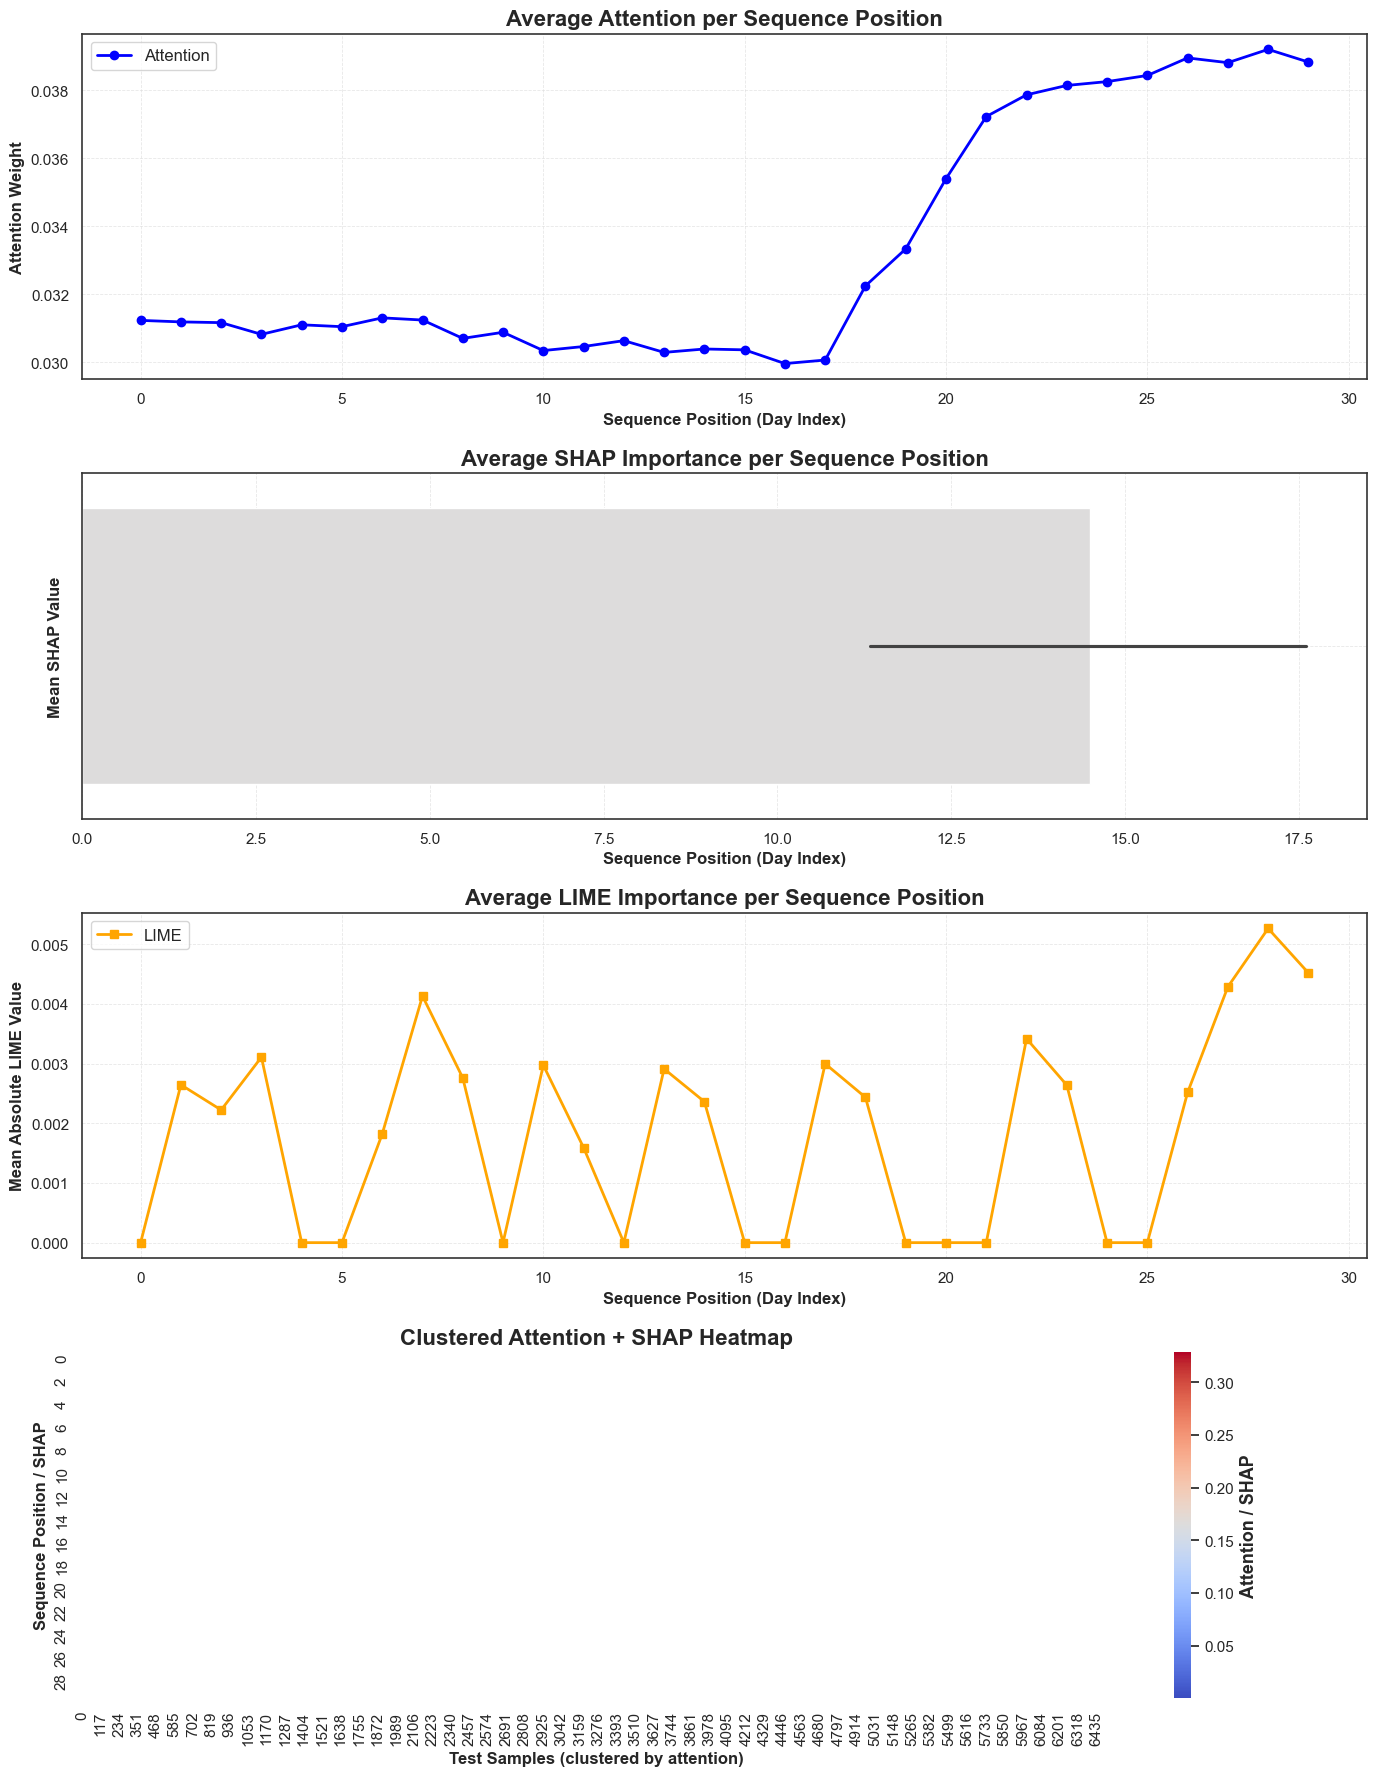

In [ ]:
DEVICE = "cpu"
model = model.to(DEVICE)
model.eval()

X_test_static = []
X_test_seq = []
y_test = []

for batch in test_loader:
    X_test_static.append(batch["static"].numpy())
    X_test_seq.append(batch["seq"].numpy())
    y_test.append(batch["y"].numpy())

X_test_static = np.vstack(X_test_static)
X_test_seq = np.vstack(X_test_seq)
y_test = np.hstack(y_test)

static_feature_names = X_static_encoded.columns.tolist()
X_test_combined = np.concatenate([X_test_static, X_test_seq], axis=1)
feature_names = static_feature_names + [f"Day_{i}" for i in range(SEQUENCE_LENGTH)]

attn_store = []

with torch.no_grad():
    for batch in test_loader:
        static = batch["static"].to(DEVICE)
        seq = batch["seq"].to(DEVICE)
        _ = model(static, seq)
        attn = model.attn_weights
        if attn is not None:
            attn_np = attn.cpu().numpy()
            attn_avg_heads = attn_np.mean(axis=1)
            if attn_avg_heads.ndim == 3 and attn_avg_heads.shape[1] == 1:
                attn_avg = attn_avg_heads.squeeze(1)
            elif attn_avg_heads.ndim == 2:
                attn_avg = attn_avg_heads
            else:
                attn_avg = attn_avg_heads.mean(axis=1)
            attn_store.append(attn_avg)

attn_mat = np.vstack(attn_store)  
avg_attn = attn_mat.mean(axis=0)

num_clusters = 4
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
attn_labels = kmeans.fit_predict(attn_mat)
sorted_idx = np.argsort(attn_labels)
attn_sorted = attn_mat[sorted_idx]

class ModelWrapper:
    def __init__(self, model):
        self.model = model
    def __call__(self, X_numpy):
        X_static = torch.tensor(X_numpy[:, :X_test_static.shape[1]], dtype=torch.float32)
        X_seq = torch.tensor(X_numpy[:, X_test_static.shape[1]:], dtype=torch.float32)
        with torch.no_grad():
            logits, _, _ = self.model(X_static, X_seq)
            probs = torch.softmax(logits, dim=1).numpy()
        return probs

wrapper = ModelWrapper(model)

background = shap.kmeans(X_test_combined, 10)
explainer_shap = shap.KernelExplainer(wrapper, background)
shap_sample = X_test_combined[:10]
shap_values = explainer_shap.shap_values(shap_sample)

seq_shap_values = np.array([s[:, X_test_static.shape[1]:] for s in shap_values])
avg_seq_shap = seq_shap_values.mean(axis=0).mean(axis=0)

lime_explainer = LimeTabularExplainer(
    training_data=X_test_combined,
    feature_names=feature_names,
    class_names=[str(c) for c in range(num_classes)],
    mode="classification"
)

lime_samples = [0,1,2]
lime_values = []
for idx in lime_samples:
    exp = lime_explainer.explain_instance(
        X_test_combined[idx],
        wrapper,
        num_features=SEQUENCE_LENGTH 
    )
    vals = np.zeros(SEQUENCE_LENGTH)
    for feat, val in exp.as_list():
        match = re.search(r'Day_(\d+)', feat)
        if match:
            day_idx = int(match.group(1))
            vals[day_idx] = abs(val)
    lime_values.append(vals)
lime_values = np.array(lime_values)
avg_lime = lime_values.mean(axis=0)

fig, axes = plt.subplots(4, 1, figsize=(14,18))

axes[0].plot(avg_attn, marker='o', linewidth=2, color='blue', label="Attention")
axes[0].set_title("Average Attention per Sequence Position", fontsize=16, fontweight='bold')
axes[0].set_xlabel("Sequence Position (Day Index)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Attention Weight", fontsize=12, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend(fontsize=12)

# SHAP importance
sns.barplot(x=np.arange(SEQUENCE_LENGTH), y=avg_seq_shap, ax=axes[1], palette="coolwarm")
axes[1].set_title("Average SHAP Importance per Sequence Position", fontsize=16, fontweight='bold')
axes[1].set_xlabel("Sequence Position (Day Index)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Mean SHAP Value", fontsize=12, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.7)

# LIME importance
axes[2].plot(avg_lime, marker='s', color='orange', linewidth=2, label="LIME")
axes[2].set_title("Average LIME Importance per Sequence Position", fontsize=16, fontweight='bold')
axes[2].set_xlabel("Sequence Position (Day Index)", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Mean Absolute LIME Value", fontsize=12, fontweight='bold')
axes[2].grid(True, linestyle='--', alpha=0.7)
axes[2].legend(fontsize=12)

combined_heatmap = np.vstack([
    attn_sorted.T, 
    np.tile(avg_seq_shap[:, None], (1, attn_sorted.shape[0]))
])

sns.heatmap(
    combined_heatmap,
    cmap="coolwarm",
    cbar_kws={"label": "Attention / SHAP"},
    ax=axes[3],
    linewidths=0.5
)
axes[3].set_title("Clustered Attention + SHAP Heatmap", fontsize=16, fontweight='bold')
axes[3].set_xlabel("Test Samples (clustered by attention)", fontsize=12, fontweight='bold')
axes[3].set_ylabel("Sequence Position / SHAP", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


100%|██████████| 5/5 [01:31<00:00, 18.31s/it]


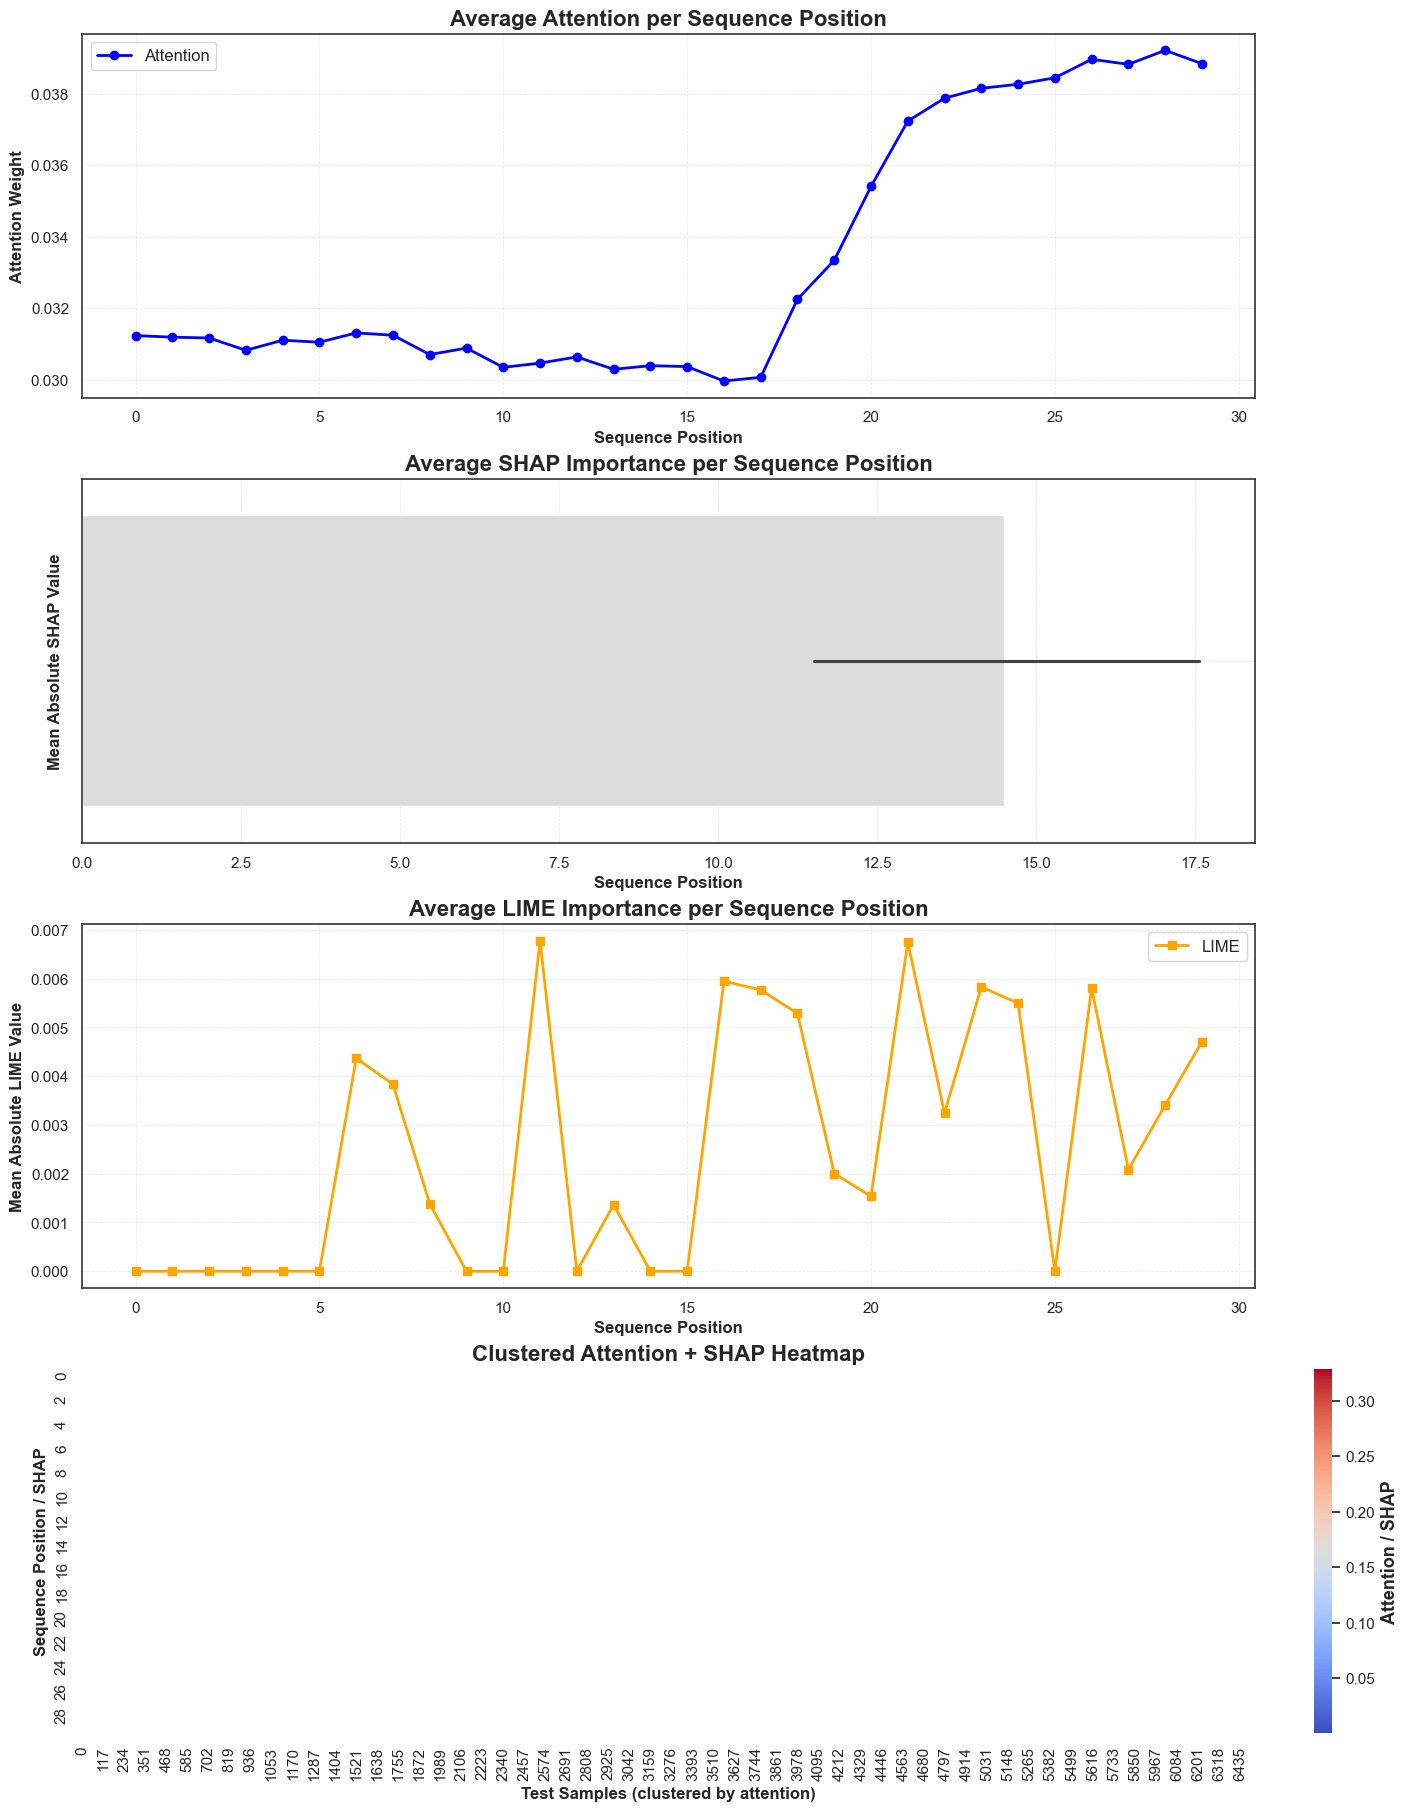

In [ ]:

DEVICE = "cpu"
model = model.to(DEVICE)
model.eval()

X_test_static, X_test_seq, y_test = [], [], []
for batch in test_loader:
    X_test_static.append(batch["static"].numpy())
    X_test_seq.append(batch["seq"].numpy())
    y_test.append(batch["y"].numpy())

X_test_static = np.vstack(X_test_static)
X_test_seq = np.vstack(X_test_seq)
y_test = np.hstack(y_test)

static_feature_names = X_static_encoded.columns.tolist()
X_test_combined = np.concatenate([X_test_static, X_test_seq], axis=1)
feature_names = static_feature_names + [f"Day_{i}" for i in range(SEQUENCE_LENGTH)]

attn_store = []
with torch.no_grad():
    for batch in test_loader:
        static = batch["static"].to(DEVICE)
        seq = batch["seq"].to(DEVICE)
        _ = model(static, seq)
        attn = model.attn_weights
        if attn is not None:
            attn_np = attn.cpu().numpy() 
            attn_avg = attn_np.mean(axis=1).mean(axis=1)
            attn_store.append(attn_avg)

attn_mat = np.vstack(attn_store)
avg_attn = attn_mat.mean(axis=0)

num_clusters = 4
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
attn_labels = kmeans.fit_predict(attn_mat)
sorted_idx = np.argsort(attn_labels)
attn_sorted = attn_mat[sorted_idx]

class ModelWrapper:
    def __init__(self, model):
        self.model = model
    def __call__(self, X_numpy):
        X_static = torch.tensor(X_numpy[:, :X_test_static.shape[1]], dtype=torch.float32)
        X_seq = torch.tensor(X_numpy[:, X_test_static.shape[1]:], dtype=torch.float32)
        with torch.no_grad():
            logits, _, _ = self.model(X_static, X_seq)
            probs = torch.softmax(logits, dim=1).numpy()
        return probs

wrapper = ModelWrapper(model)
background = shap.kmeans(X_test_combined, 10)
explainer = shap.KernelExplainer(wrapper, background)
shap_sample = X_test_combined[:min(5, X_test_combined.shape[0])] 
shap_values = explainer.shap_values(shap_sample)

# Extract sequence SHAP values
seq_shap = np.array([s[:, X_test_static.shape[1]:] for s in shap_values]) 
avg_seq_shap = seq_shap.mean(axis=0).mean(axis=0) 

lime_explainer = LimeTabularExplainer(
    training_data=X_test_combined,
    feature_names=feature_names,
    class_names=[str(c) for c in range(num_classes)],
    mode="classification"
)

lime_samples = [0,1,2]
lime_vals = []
for idx in lime_samples:
    exp = lime_explainer.explain_instance(X_test_combined[idx], wrapper, num_features=SEQUENCE_LENGTH)
    vals = np.zeros(SEQUENCE_LENGTH)
    for feat, val in exp.as_list():
        if "Day_" in feat:
            try:
                day_idx = int(feat.split("_")[1].split()[0])
                vals[day_idx] = abs(val)
            except:
                continue
    lime_vals.append(vals)

lime_vals = np.array(lime_vals)
avg_lime = lime_vals.mean(axis=0) 

fig, axes = plt.subplots(4, 1, figsize=(14, 18), constrained_layout=True)

axes[0].plot(avg_attn, marker='o', color='blue', linewidth=2, label="Attention")
axes[0].set_title("Average Attention per Sequence Position", fontsize=16, fontweight='bold')
axes[0].set_xlabel("Sequence Position", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Attention Weight", fontsize=12, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(fontsize=12)

sns.barplot(x=np.arange(SEQUENCE_LENGTH), y=avg_seq_shap, ax=axes[1], palette="coolwarm")
axes[1].set_title("Average SHAP Importance per Sequence Position", fontsize=16, fontweight='bold')
axes[1].set_xlabel("Sequence Position", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Mean Absolute SHAP Value", fontsize=12, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.6)

axes[2].plot(avg_lime, marker='s', color='orange', linewidth=2, label="LIME")
axes[2].set_title("Average LIME Importance per Sequence Position", fontsize=16, fontweight='bold')
axes[2].set_xlabel("Sequence Position", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Mean Absolute LIME Value", fontsize=12, fontweight='bold')
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend(fontsize=12)

combined_heatmap = np.vstack([attn_sorted.T, np.tile(avg_seq_shap[:, None], (1, attn_sorted.shape[0]))])
sns.heatmap(
    combined_heatmap,
    cmap="coolwarm",
    cbar_kws={"label": "Attention / SHAP"},
    ax=axes[3],
    linewidths=0.5
)
axes[3].set_title("Clustered Attention + SHAP Heatmap", fontsize=16, fontweight='bold')
axes[3].set_xlabel("Test Samples (clustered by attention)", fontsize=12, fontweight='bold')
axes[3].set_ylabel("Sequence Position / SHAP", fontsize=12, fontweight='bold')

plt.show()


100%|██████████| 20/20 [00:13<00:00,  1.53it/s]


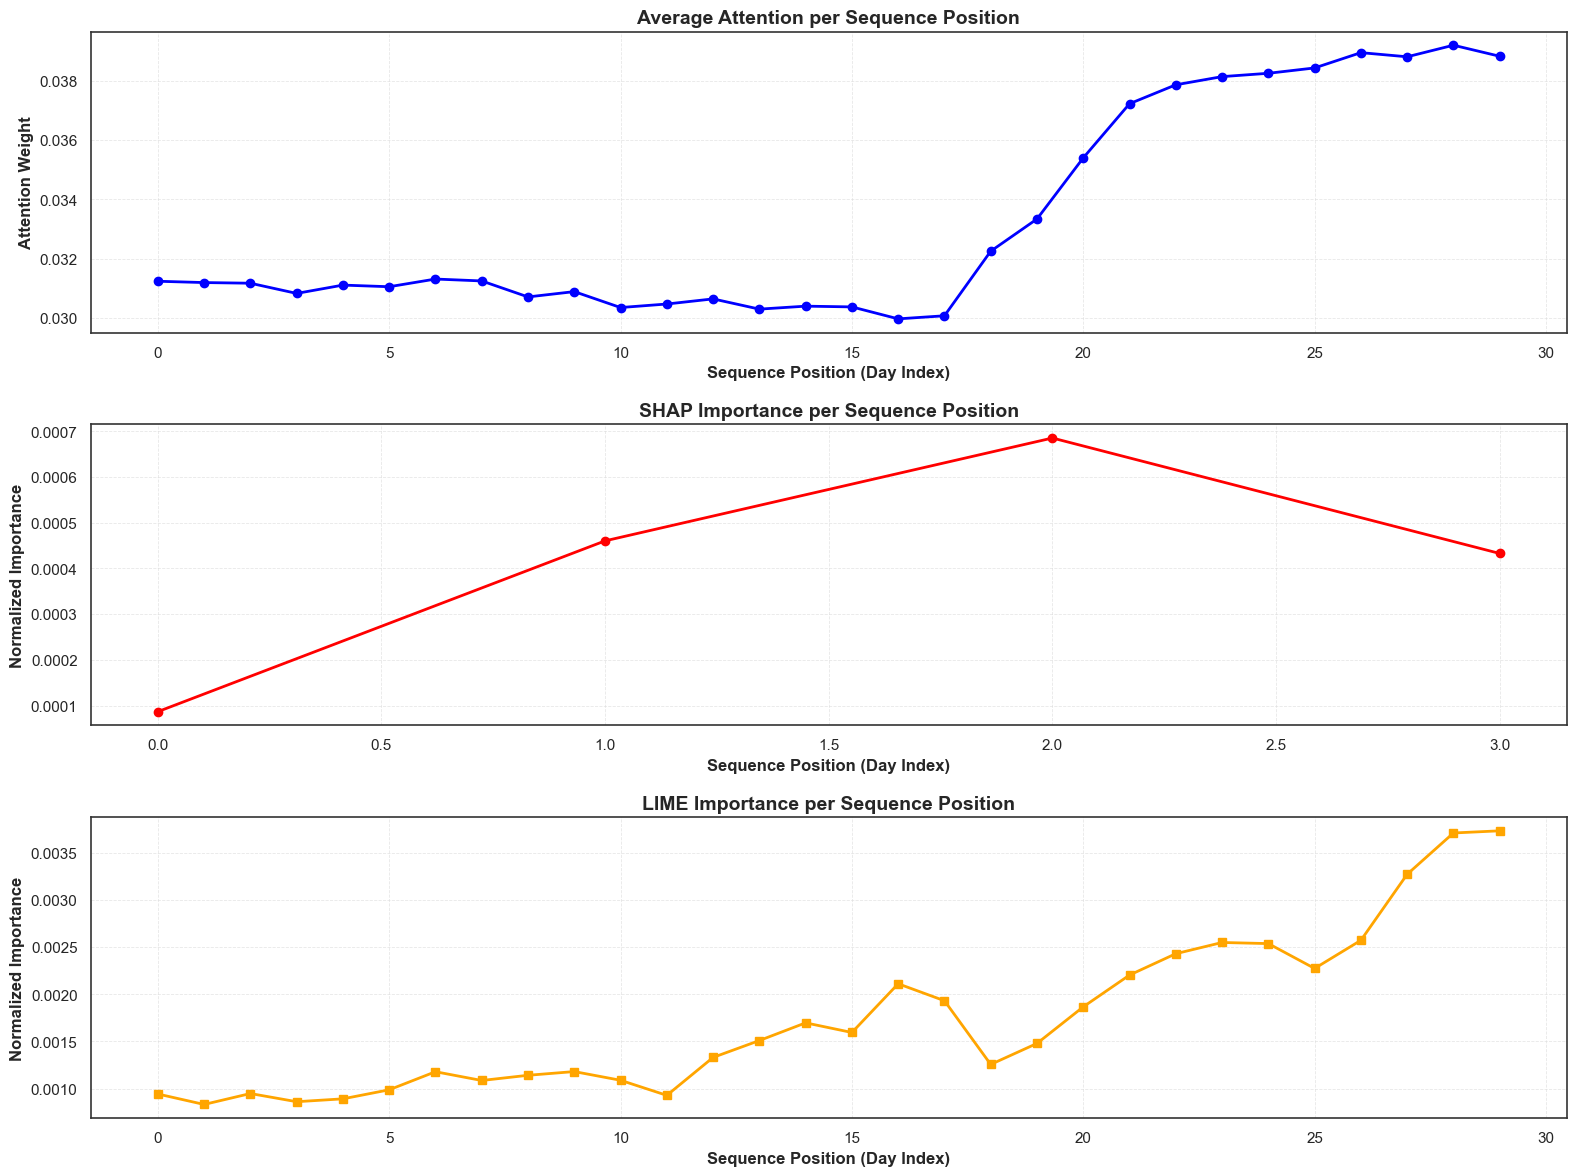

In [ ]:
DEVICE = "cpu"
model = model.to(DEVICE)
model.eval()


X_test_static, X_test_seq, y_test = [], [], []

for batch in test_loader:
    X_test_static.append(batch["static"].numpy())
    X_test_seq.append(batch["seq"].numpy())
    y_test.append(batch["y"].numpy())

X_test_static = np.vstack(X_test_static)
X_test_seq = np.vstack(X_test_seq)
y_test = np.hstack(y_test)

seq_feature_names = [f"Day_{i}" for i in range(SEQUENCE_LENGTH)]

def model_wrapper(X_numpy):
    X_tensor = torch.tensor(X_numpy, dtype=torch.float32, device=DEVICE)
    static_x = X_tensor[:, :X_test_static.shape[1]]
    seq_x = X_tensor[:, X_test_static.shape[1]:]
    with torch.no_grad():
        logits, _, _ = model(static_x, seq_x)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
    return probs

attn_store = []
with torch.no_grad():
    for batch in test_loader:
        static = batch["static"].to(DEVICE)
        seq = batch["seq"].to(DEVICE)
        _ = model(static, seq)
        attn = model.attn_weights
        if attn is not None:
            attn_np = attn.cpu().numpy()
            if attn_np.ndim == 4:
                attn_avg = attn_np.mean(axis=(1,2)) 
            else:
                attn_avg = attn_np.mean(axis=1)
            attn_store.append(attn_avg)

attn_mat = np.vstack(attn_store)
avg_attn = attn_mat.mean(axis=0)

shap_subset = X_test_seq[:20]
background = shap_subset[:10]
explainer_shap = shap.KernelExplainer(
    lambda x: model_wrapper(np.concatenate([np.zeros((x.shape[0], X_test_static.shape[1])), x], axis=1)),
    background
)
shap_values = explainer_shap.shap_values(shap_subset, nsamples=50)
shap_array = np.array([np.abs(s) for s in shap_values])
avg_shap = shap_array.mean(axis=(0,1)) 

lime_explainer = LimeTabularExplainer(
    training_data=X_test_seq,
    feature_names=seq_feature_names,
    class_names=[str(c) for c in range(num_classes)],
    mode="classification"
)

lime_samples = [0,1,2]
lime_values = []
for idx in lime_samples:
    exp = lime_explainer.explain_instance(
        X_test_seq[idx],
        lambda x: model_wrapper(np.concatenate([np.zeros((x.shape[0], X_test_static.shape[1])), x], axis=1)),
        num_features=SEQUENCE_LENGTH
    )
    vals = np.zeros(SEQUENCE_LENGTH)
    for feat, val in exp.as_list():
        match = re.search(r'Day_(\d+)', feat)
        if match:
            day_idx = int(match.group(1))
            vals[day_idx] = abs(val)
    lime_values.append(vals)

lime_values = np.array(lime_values)
avg_lime = lime_values.mean(axis=0)

fig, axes = plt.subplots(3, 1, figsize=(16,12))

axes[0].plot(avg_attn, marker='o', color='blue', linewidth=2)
axes[0].set_title("Average Attention per Sequence Position", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Sequence Position (Day Index)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Attention Weight", fontsize=12, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.7)


axes[1].plot(avg_shap, marker='o', color='red', linewidth=2)
axes[1].set_title("SHAP Importance per Sequence Position", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Sequence Position (Day Index)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Normalized Importance", fontsize=12, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.7)

axes[2].plot(avg_lime, marker='s', color='orange', linewidth=2)
axes[2].set_title("LIME Importance per Sequence Position", fontsize=14, fontweight='bold')
axes[2].set_xlabel("Sequence Position (Day Index)", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Normalized Importance", fontsize=12, fontweight='bold')
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [ ]:
folders_to_zip = [os.path.join(DATA_PATH, "models"), os.path.join(DATA_PATH, "models_htbt")]
zip_output = os.path.join(DATA_PATH, "htbt_models.zip")

with zipfile.ZipFile(zip_output, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for folder in folders_to_zip:
        folder_path = Path(folder)
        for file_path in folder_path.rglob("*"):
            zipf.write(file_path, arcname=file_path.relative_to(folder_path.parent))

print(f"Zipped to {zip_output}")



Zipped to C:\Users\acer\Desktop\PhD materials\Manuscripts\DataSets\anonymisedData\htbt_models.zip
